# Mercado Laboral Colombiano
**Autores:** Andrés Parejo, Santiago Hurtado, Juan Marín

<a href="https://www.youtube.com/watch?v=2pBUO-to_KM" target="_blank">Mira nuestro video de YouTube!</a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde, linregress
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

# Introducción

El mercado laboral constituye uno de los principales indicadores del desempeño económico de un país, ya que refleja la capacidad de la economía de generar empleo. Su análisis permite comprender la interacción entre la oferta laboral y la demanda de trabajo, así como evaluar el funcionamiento general de la economía en términos de producción y generación de ingresos.

Este seguimiento se realiza a partir de la Gran Encuesta Integrada de Hogares (GEIH), elaborada por el Departamento Administrativo Nacional de Estadística (DANE). Esta recoge y se constituye principalmente de información como lo son los indicadores los cuales caracterizan la dinámica del empleo y desempleo en el país. El análisis de estos indicadores resulta fundamental no solo para describir el mercado laboral, sino para identificar tendencias, posibles desequilibrios en el futuro y ciclos.  

El presente proyecto tiene objetivo analizar el comportamiento del mercado laboral colombiano a partir de esos indicadores mensuales publicados por el Banco e la Republica y producidos por el DANE, para el periodo comprendidos entre enero de 2001 y diciembre de 2025. A partir de esta información, se busca realizar un análisis descriptivo y temporal que permita identificar patrones relevantes  en la evolución del empleo, así como posibles cambios asociados a choques económicos, cambios estructurales o ajustes en la medición estadística.
Este estudio pretende aportar una visión más integral y basada en los datos sobre el mercado laboral colombiano, contribuyendo a una mejor comprensión de su dinámica generando información útil para la toma de decisiones económicas y el diseño de políticas orientadas a mejorar las condiciones del empleo en el país.


Las variables analizadas son las siguientes:

### Tasa Global de Participación – 13 áreas (TGP área).

- **Definición:** Relación porcentual entre la población que integra la fuerza de trabajo y la población en edad de trabajar en las 13 principales áreas metropolitanas.  
- **Tipo de variable:** Cuantitativa continua  
- **Escala de medición:** Razón  
- **Unidad de medida:** Porcentaje (%)  
- **Frecuencia:** Mensual  
- **Interpretación:** Mide el grado de participación laboral en las principales zonas urbanas, reflejando la presión de la población sobre el mercado laboral.

### Tasa Global de Participación – Total nacional (TGP nacional).

- **Definición:** Relación porcentual entre la fuerza de trabajo y la población en edad de trabajar a nivel nacional.  
- **Tipo de variable:** Cuantitativa continua  
- **Escala de medición:** Razón  
- **Unidad de medida:** Porcentaje (%)  
- **Frecuencia:** Mensual  
- **Interpretación:** Permite evaluar la participación laboral agregada del país, incluyendo zonas urbanas y rurales.

### Tasa de Desempleo – 13 áreas.

- **Definición:** Relación porcentual entre la población desocupada y la fuerza de trabajo en las 13 principales áreas metropolitanas.  
- **Tipo de variable:** Cuantitativa continua  
- **Escala de medición:** Razón  
- **Unidad de medida:** Porcentaje (%)  
- **Frecuencia:** Mensual  
- **Interpretación:** Indica la proporción de personas que buscan empleo sin encontrarlo en los principales centros urbanos.

### Tasa de Desempleo – Total nacional.

- **Definición:** Relación porcentual entre la población desocupada y la fuerza de trabajo a nivel nacional.  
- **Tipo de variable:** Cuantitativa continua  
- **Escala de medición:** Razón  
- **Unidad de medida:** Porcentaje (%)  
- **Frecuencia:** Mensual  
- **Interpretación:** Refleja el nivel de desempleo en todo el país, capturando diferencias entre regiones urbanas y rurales.

### Tasa de Ocupación – 13 áreas.

- **Definición:** Relación porcentual entre la población ocupada y la población en edad de trabajar en las 13 principales áreas metropolitanas.  
- **Tipo de variable:** Cuantitativa continua  
- **Escala de medición:** Razón  
- **Unidad de medida:** Porcentaje (%)  
- **Frecuencia:** Mensual  
- **Interpretación:** Mide el nivel de empleo efectivo en las principales ciudades, evidenciando el grado de absorción de la fuerza laboral.

### Tasa de Ocupación – Total nacional.

- **Definición:** Relación porcentual entre la población ocupada y la población en edad de trabajar a nivel nacional.  
- **Tipo de variable:** Cuantitativa continua  
- **Escala de medición:** Razón  
- **Unidad de medida:** Porcentaje (%)  
- **Frecuencia:** Mensual  
- **Interpretación:** Permite evaluar el nivel general de empleo en el país y comparar su evolución con las áreas urbanas.

Dado que todas las variables son **cuantitativas continuas y de frecuencia mensual**, el análisis es consistente con metodologías de **series de tiempo**, permitiendo aplicar herramientas como análisis de tendencias, correlación, descomposición temporal y modelos econométricos.
A partir de esta variable, se busca responder la siguiente pregunta de investigación:

**¿Cómo ha evolucionado la tasa de desempleo en Colombia a lo largo del tiempo y qué relación presenta con otros indicadores del mercado laboral como la tasa de ocupación y la tasa global de participación?**

### Justificación.

El mercado laboral colombiano ha experimentado transformaciones en el pasar de los años marcadas por periodos de recuperación economica, reformas estructurales y choques económicos como lo fue la pandemia. A pesar de que el DANE publica de forma periodica los principales indicadores laborales a traves de sus encuestas, no siempre hay un análisis integrado y de largo plazo que permita comprender la dinamica conjunta de estos indicadores y su evolución histórica.
Este proyecto se justifica por el valor y la necesidad de contar una vision analitica, basada en datos, sobre el periodo que comprende el dataset (2001-2025).

Desde una perspectiva de politica economica, este tipo de análisis resulta de gran importancia para poder orientar en decisiones en materia de empleo, formación laboral y diseño de programas sociales. Asimismo, usando técnicas y herramientas para su análisis intenso, visualizaciones interactivas, pero rigurosas y un modelado predictivo. Al final se busca una combinación de una muy buena estadística con la capacidad de comunicar los resultados para que el publico lector le sea mas claro y sensible.

### Objetivo general

Analizar la evolución de la tasa de desempleo en Colombia a lo largo del tiempo y su relación con otros indicadores del mercado laboral, mediante el desarrollo de un dashboard interactivo y la implementación de un modelo predictivo que permita identificar patrones y apoyar el análisis del comportamiento del empleo.

### Objetivos específicos

- Explorar y visualizar el comportamiento histórico de la tasa de desempleo, la tasa de ocupación y la tasa global de participación en Colombia mediante análisis exploratorio de datos.

- Diseñar y desarrollar un dashboard interactivo que permita analizar de forma dinámica la evolución y la relación entre los principales indicadores del mercado laboral.

- Implementar y evaluar un modelo de predicción que permita estimar la evolución de la tasa de desempleo a partir de su comportamiento histórico y su relación con otros indicadores laborales.

### Marco teórico.

#### 1. El mercado laboral: oferta, demanda y mecanismos de ajuste

El mercado laboral se define como el espacio económico en el que interactúan la oferta y la demanda de trabajo. El salario actúa como el mecanismo de ajuste que equilibra estas fuerzas: cuando la demanda de trabajo supera la oferta, los salarios tienden a subir, incentivando una mayor participación laboral; cuando ocurre lo contrario, el desempleo surge como consecuencia de un exceso de oferta (Mankiw, 2015). Sin embargo, este ajuste rara vez es inmediato ni perfecto, dado que existen fricciones e instituciones que afectan o distorsionan el equilibrio.

Desde la perspectiva keynesiana, el desempleo puede persistir incluso en equilibrio cuando la demanda agregada es insuficiente para absorber toda la oferta laboral disponible (Keynes, 1936). Esta visión contrasta con el enfoque neoclásico, que postula que el mercado tiende al pleno empleo en el largo plazo, y con el concepto de tasa natural de desempleo desarrollado por Friedman (1968), según el cual existe un nivel de desempleo estructural y friccional que la política monetaria no puede reducir de forma permanente.

#### 2. Fricciones, búsqueda y emparejamiento

Los modelos de búsqueda y emparejamiento (*search and matching*), desarrollados principalmente por Pissarides (2000) y Diamond, ofrecen un marco analítico para entender por qué el desempleo persiste incluso en economías dinámicas. En estos modelos, trabajadores y empresas incurren en costos de búsqueda y el proceso de emparejamiento no es instantáneo, lo que genera desempleo friccional. La curva de Beveridge —que relaciona inversamente las vacantes y el desempleo— constituye una representación empírica central de este enfoque (Blanchard & Diamond, 1989).

Adicionalmente, el fenómeno de histéresis, documentado por Blanchard y Summers (1987), sugiere que choques temporales sobre el desempleo pueden generar efectos permanentes sobre la tasa natural, especialmente cuando los trabajadores desempleados pierden capital humano o son excluidos del proceso de negociación salarial.

#### 3. Indicadores del mercado laboral colombiano

Para un mejor entendimiento del comportamiento del mercado laboral colombiano, el DANE utiliza definiciones establecidas por la Organización Internacional del Trabajo (OIT). Bajo estos conceptos, la población en edad de trabajar (PET) se divide en población económicamente activa (PEA o fuerza de trabajo) y población económicamente inactiva. A su vez, la PEA se subdivide en ocupados y desocupados, lo que da lugar a los tres indicadores centrales de este estudio:

- La **tasa global de participación** mide la proporción de la PET que hace parte de la fuerza laboral.
- La **tasa de ocupación** indica el porcentaje de la PET que se encuentra efectivamente trabajando.
- La **tasa de desempleo** señala la proporción de la fuerza de trabajo que está disponible y buscando empleo pero no lo encuentra.

Estos tres indicadores no son independientes entre sí y deben analizarse de forma conjunta para comprender la dinámica del mercado laboral.

#### 4. Series de tiempo y modelado econométrico

Desde el enfoque de las series de tiempo, el mercado laboral presenta componentes que lo hacen complejo: tendencias a largo plazo asociadas a cambios demográficos, ciclos y choques económicos, y estacionalidades derivadas de contrataciones en ciertas épocas del año. Para su análisis riguroso se emplean modelos ARIMA y, más recientemente, modelos de machine learning aplicados a la predicción de series temporales económicas (Hyndman & Athanasopoulos, 2021).

En el contexto colombiano, trabajos como el de Arango, Herrera y Posada (2008) han documentado la persistencia del desempleo y la importancia de factores institucionales en su determinación, mientras que el Banco de la República ha señalado reiteradamente el impacto diferencial de los choques externos sobre el empleo. El periodo 2020–2021 generó una ruptura estructural que cualquier modelo predictivo debe contemplar con especial atención.

### Hipótesis.

**Hipótesis principal:**
La tasa de desempleo nacional en Colombia presenta una relación inversa y estadísticamente significativa con la tasa de ocupación nacional y con la tasa global de participación, y su evolución histórica evidencia patrones cíclicos y estacionales que pueden ser modelados a partir del comportamiento pasado de la propia serie y de los indicadores relacionados.

**Hipótesis secundarias:**

1. El comportamiento de la tasa de desempleo en las 13 principales áreas metropolitanas es un predictor consistente del desempleo a nivel nacional, dada la alta correlación estructural entre ambas series.
2. El choque generado por la pandemia de COVID-19 en 2020 constituye una ruptura estructural en las series del mercado laboral colombiano, diferenciable estadísticamente del comportamiento histórico previo.
3. La variabilidad estacional del desempleo es un componente recurrente y modelable dentro de la serie histórica analizada.

### Metodología.

El estudio adopta un enfoque cuantitativo. Dado que las observaciones corresponden a mediciones mensuales de los indicadores del mercado laboral colombiano a través del tiempo, se enmarca dentro de la metodología de series de tiempo, lo que implica que el orden cronológico de las observaciones es un elemento fundamental para el modelado de los datos.

El proyecto contiene 3 fases:

**Primera fase - Análisis Exploratorio de Datos (EDA):** En esta etapa constituye el núcleo del presente proyecto que se divide a su vez en dos niveles.

- Análisis univariado: Se examina el comportamiento individual de cada variable mediante estadísticos descriptivos y gráficos. Se realiza un exploratorio de cada una de las variables por separado para que no afecten a futuro y tampoco generen sesgos o respuestas incorrectas a la pregunta problema.

- Análisis bivariado: Se evalúan las relaciones entre la variable objetivo y las demás variables del dataset. Este punto es clave ya que más adelante para la realización del modelo nos dice que variables vale la pena incluir y cuales no tienen relación relevante.

**Segunda fase - Visualización interactiva:** Con base en los gráficos y patrones identificados en el EDA, se realizará un dashboard interactivo tanto en Shiny como en Dash.

**Tercera fase - Modelado predictivo:** Se procederá a implementar un modelo de predicción. Dado el carácter temporal de los datos, tendencias y choques, el modelo deberá ser capaz de capturar esas características.

# EDA

El Análisis Exploratorio de Datos (EDA) se realiza con el objetivo de comprender la estructura y el comportamiento de los indicadores del mercado laboral en Colombia antes de aplicar análisis más avanzados. A través de herramientas como histogramas, diagramas de caja, gráficos de dispersión y matrices de correlación, se busca identificar la distribución de las variables, detectar valores atípicos y analizar las relaciones entre la tasa de desempleo nacional (variable objetivo) y otros indicadores como la tasa de ocupación y la tasa global de participación, permitiendo obtener una primera comprensión de la dinámica del mercado laboral en el período analizado.

- Se hace una carga de los datos:

In [2]:
import pandas as pd

MLC = pd.read_excel(
    "C:/Users/boolean/Downloads/MLC.xlsx",
    sheet_name="Series de datos",
    dtype={
        "tasa_global_participacion_area":     float,
        "tasa_global_participacion_nacional": float,
        "tasa_desempleo_area":                float,
        "tasa_desempleo_nacional":            float,
        "tasa_ocupacion_area":                float,
        "tasa_ocupacion_nacional":            float,
    },
    parse_dates=["fecha"]
)

MLC.head()

,fecha,tasa_global_participacion_area,tasa_global_participacion_nacional,tasa_desempleo_area,tasa_desempleo_nacional,tasa_ocupacion_area,tasa_ocupacion_nacional
0,2001-01-31,70.0177,69.053538,20.7176,16.622326,55.5117,57.575237
1,2001-02-28,70.2342,68.948903,19.5518,17.434206,56.5021,56.928209
2,2001-03-31,69.1487,68.387911,19.1240,15.811933,55.9247,57.574460
3,2001-04-30,67.7233,65.224009,17.5699,14.515078,55.8244,55.756693
4,2001-05-31,68.0567,65.406094,17.7675,14.035833,55.9647,56.225804


Se realiza una inspección inicial de los datos del dataset:

In [3]:
print(MLC.columns.tolist())
print(MLC.dtypes)
print(MLC.shape)
MLC.describe()

['fecha', 'tasa_global_participacion_area', 'tasa_global_participacion_nacional', 'tasa_desempleo_area', 'tasa_desempleo_nacional', 'tasa_ocupacion_area', 'tasa_ocupacion_nacional']
fecha                                 datetime64[ns]
tasa_global_participacion_area               float64
tasa_global_participacion_nacional           float64
tasa_desempleo_area                          float64
tasa_desempleo_nacional                      float64
tasa_ocupacion_area                          float64
tasa_ocupacion_nacional                      float64
dtype: object
(300, 7)


,fecha,tasa_global_participacion_area,tasa_global_participacion_nacional,tasa_desempleo_area,tasa_desempleo_nacional,tasa_ocupacion_area,tasa_ocupacion_nacional
count,300,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,2013-07-15 18:38:24,67.759280,65.740493,12.627463,11.612474,59.217590,58.120190
min,2001-01-31 00:00:00,55.088000,53.445600,7.270000,7.020000,41.658000,42.497100
25%,2007-04-22 12:00:00,66.565228,64.086900,10.449650,9.735275,57.706275,56.840939
50%,2013-07-15 12:00:00,67.953800,66.138590,11.730200,11.192750,59.587851,58.315000
75%,2019-10-07 18:00:00,69.468850,67.482400,14.021275,12.909062,61.128426,59.960250
max,2025-12-31 00:00:00,72.147900,70.617500,25.788700,21.972000,64.609700,64.008000
std,NaN,2.224336,2.346308,3.147355,2.448868,3.097003,2.854977


Verificamos que no hayan datos faltantes ni casillas vacias:

In [4]:
MLC.isnull().sum()

fecha                                 0
tasa_global_participacion_area        0
tasa_global_participacion_nacional    0
tasa_desempleo_area                   0
tasa_desempleo_nacional               0
tasa_ocupacion_area                   0
tasa_ocupacion_nacional               0
dtype: int64

En efecto, no encontramos ningún NA. Esto nos facilita el trabajar con los datos que la limpieza no debe ser tan rigurosa.
Otra forma de verlo sería:

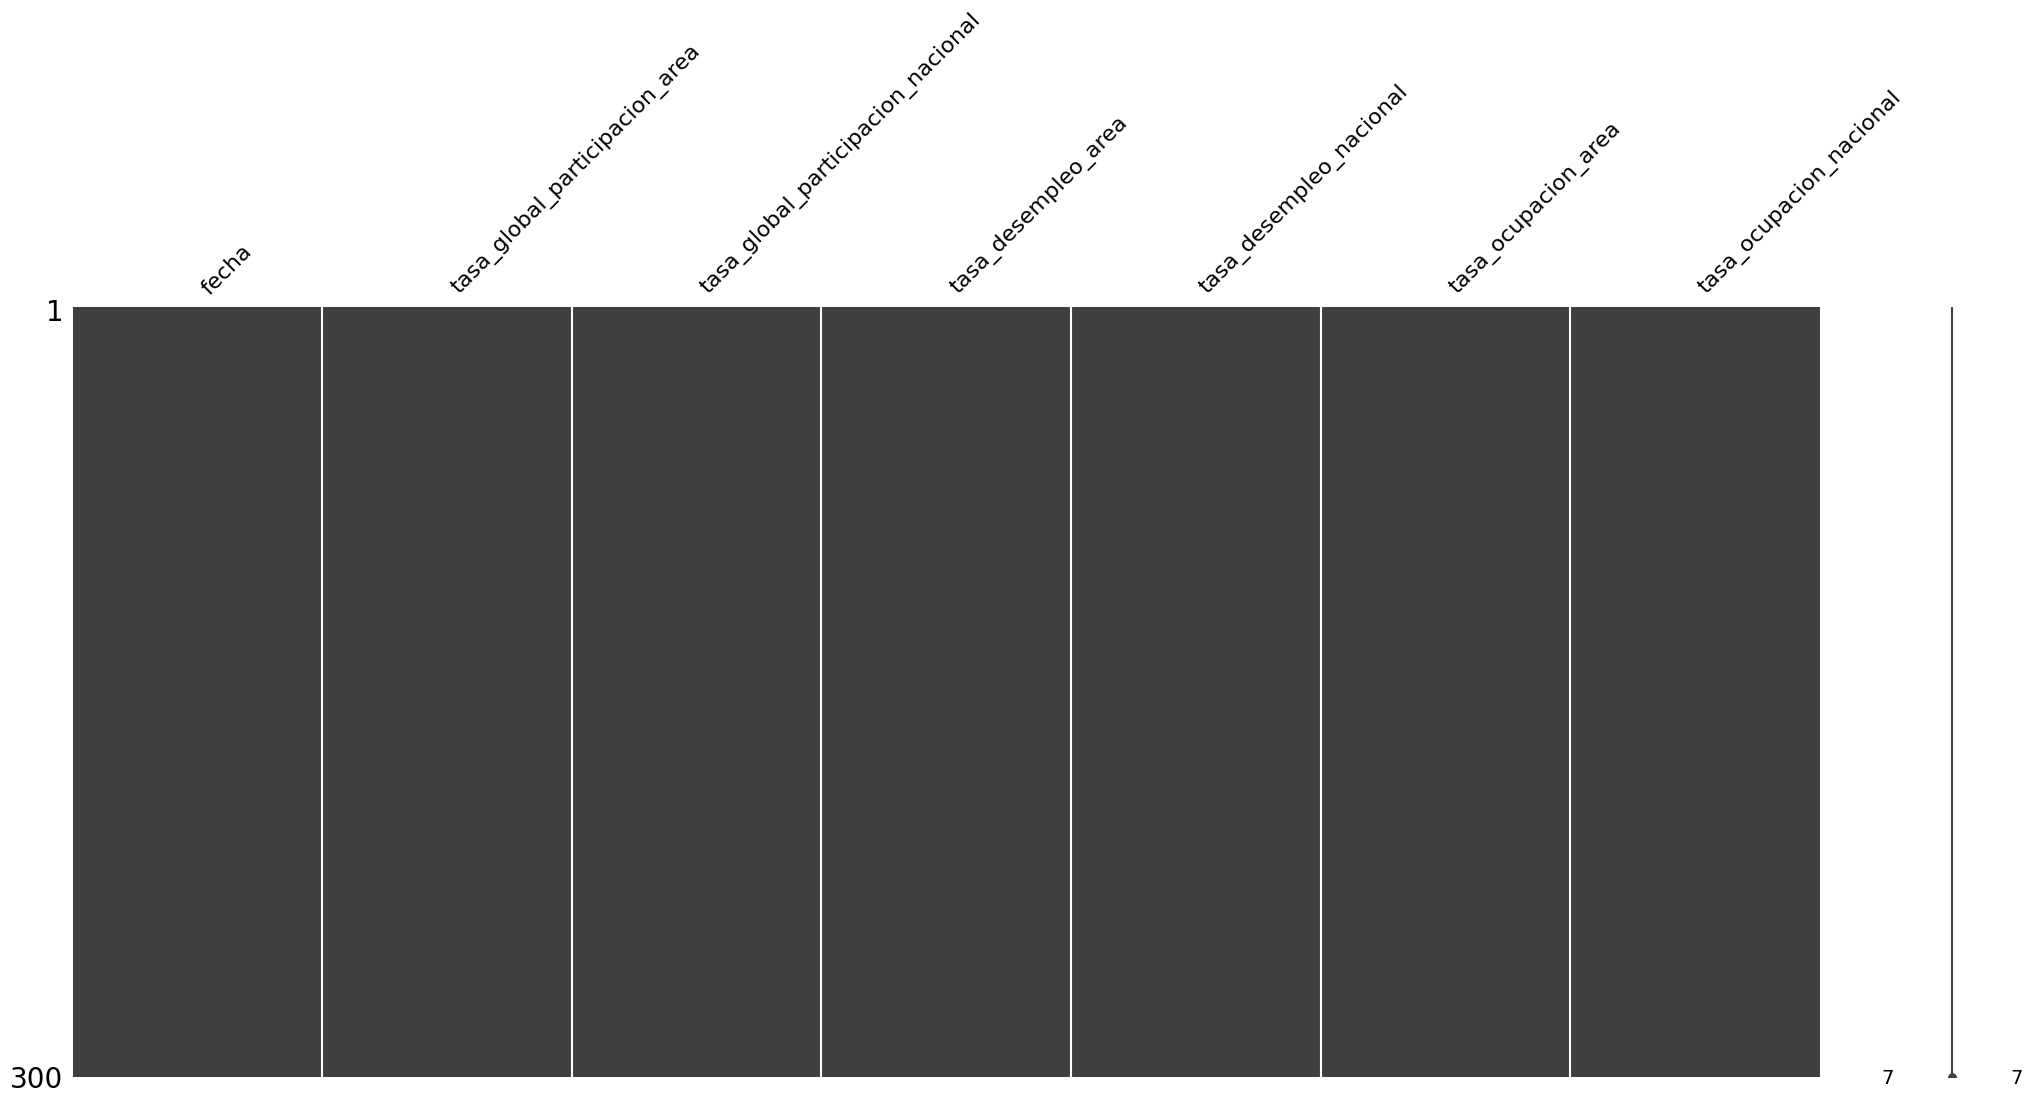

In [5]:
import missingno as msno

msno.matrix(MLC)
plt.show()

### Analisis de la variable tasa_desempleo_nacional.

Consideremos el resumen de tasa_desempleo_nacional (objetivo):

In [6]:
col = MLC['tasa_desempleo_nacional']

resumen = {
    'n':       len(col),
    'media':   col.mean(),
    'ds':      col.std(),
    'mediana': col.median(),
    'minimo':  col.min(),
    'maximo':  col.max(),
    'Q1':      col.quantile(0.25),
    'Q3':      col.quantile(0.75),
    'IQR':     col.quantile(0.75) - col.quantile(0.25),
}

pd.DataFrame([resumen])

,n,media,ds,mediana,minimo,maximo,Q1,Q3,IQR
0,300,11.612474,2.448868,11.19275,7.02,21.972,9.735275,12.909062,3.173787


La variable tasa_desempleo_nacional fue analizada a partir de 300 observaciones. Se obtuvo una media de 11.61247 que se refleja como la tasa de desempleo nacional que se refleja como porcentaje, donde la mitad de la muestra se encuentr por debajo de 11.19275.
El minimo registrado fue de 7.02, lo que indica que en una fecha en especifico se presentó una tasa de desempleo menor a la media. Por su parte el maximo fue de 21.972, lo cual refleja una tasa de desempleo alta en una fecha en especifico.

- Con el fin de analizar la distribución de la variable tasa de desempleo nacional, se construye un histograma. Este grafico permite visualizar la concentración de los valores, identifica posibles asimetrías en la distribución, ayuda fundamentalmente para caracterizar la variable antes de estudiar sus relaciones con otros indicadores del mercado laboral.

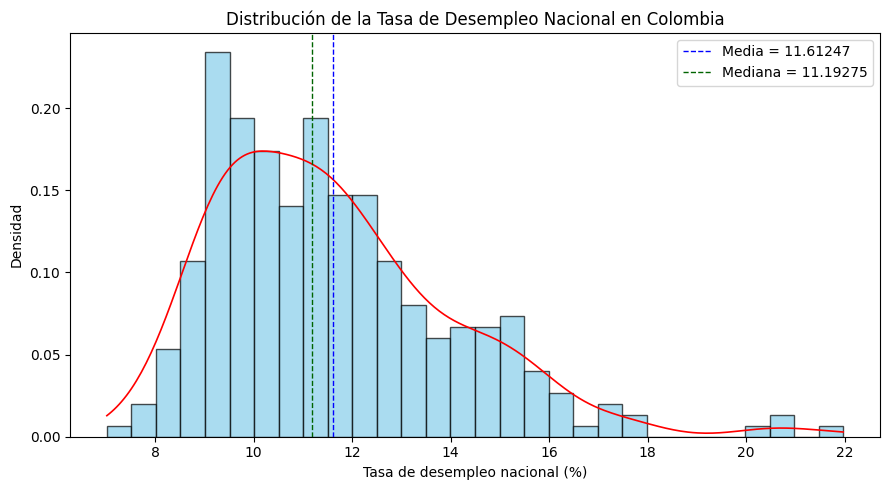

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

media_des   = MLC['tasa_desempleo_nacional'].mean()
mediana_des = MLC['tasa_desempleo_nacional'].median()

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    MLC['tasa_desempleo_nacional'],
    bins=30,
    density=True,
    color='skyblue',
    edgecolor='black',
    alpha=0.7
)

kde_x = np.linspace(MLC['tasa_desempleo_nacional'].min(),
                    MLC['tasa_desempleo_nacional'].max(), 300)
kde   = gaussian_kde(MLC['tasa_desempleo_nacional'])
ax.plot(kde_x, kde(kde_x), color='red', linewidth=1.2)

ax.axvline(media_des,   color='blue',      linestyle='--', linewidth=1.0,
           label=f'Media = {media_des:.5f}')
ax.axvline(mediana_des, color='darkgreen', linestyle='--', linewidth=1.0,
           label=f'Mediana = {mediana_des:.5f}')

ax.set_title('Distribución de la Tasa de Desempleo Nacional en Colombia')
ax.set_xlabel('Tasa de desempleo nacional (%)')
ax.set_ylabel('Densidad')
ax.legend()
plt.tight_layout()
plt.show()

El histograma presenta la distribución de frecuencias de la tasa de desempleo nacional. En el eje horizontal se ubican los intervalos de la variable (10, 15 y 20), mientras que el eje vertical muestra la frecuencia de observaciones en cada rango, con un máximo de 20.

La altura de las barras permite identificar la concentración de los datos. Si las frecuencias más altas se encuentran en los intervalos inferiores (cercanos a 10), predominan tasas de desempleo bajas. Por el contrario, si se concentran en valores superiores (cercanos a 20), predominan tasas altas. Este análisis visual facilita la comprensión del comportamiento del desempleo en el período estudiado y constituye una base descriptiva fundamental para estudios económicos y sociales.

- Para complementar el análisis del histograma, se construye un boxplot. Este tipo de visualización resume la distribución de la variable mediante sus cuantiles, analizar su dispersion de los datos a traves del rango intercuartílico y además facilita la detección de valores atípicos.- Realicemos un grafico de caja y bigote:

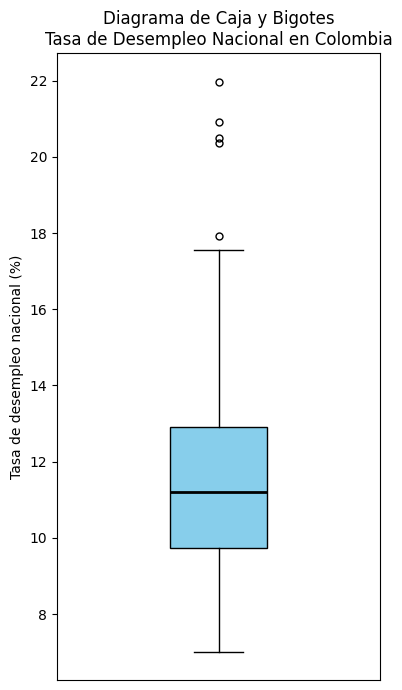

In [8]:
fig, ax = plt.subplots(figsize=(4, 7))

ax.boxplot(
    MLC['tasa_desempleo_nacional'],
    patch_artist=True,
    boxprops=dict(facecolor='skyblue', color='black'),
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    flierprops=dict(marker='o', color='red', markersize=5),
    widths=0.3
)

ax.set_title('Diagrama de Caja y Bigotes\nTasa de Desempleo Nacional en Colombia')
ax.set_ylabel('Tasa de desempleo nacional (%)')
ax.set_xticks([])
plt.tight_layout()
plt.show()

Se identifican tres puntos rojos fuera de este rango, lo que indica la presencia de valores atípicos o outliers: uno en el 20%, dos en el 15% y uno en el 10%. Estos valores se desvían del comportamiento general de la serie, posiblemente reflejando periodos con condiciones económicas excepcionales, como crisis o recuperaciones atípicas.
Se reflejan unos outliers, pero al ser el dataset economico se mantendrá por ahora.

- Una vez analizada la distribución de las variables mediante histogramas y detectados posibles valores atípicos con boxplot, se emplea el gráfico de dispersión con el fin de visualizar cada observación individualmente. Este tipo de gráfico permite confirmar la presencia de outliers, identificar patrones en los datos y complementar el análisis exploratorio previo.

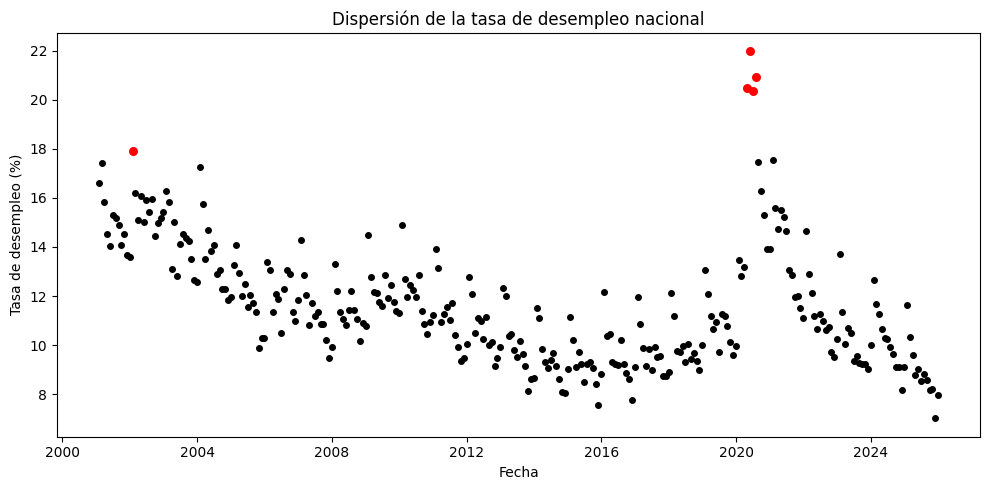

In [9]:
Q1      = MLC['tasa_desempleo_nacional'].quantile(0.25)
Q3      = MLC['tasa_desempleo_nacional'].quantile(0.75)
IQR_val = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR_val
lim_sup = Q3 + 1.5 * IQR_val

outliers = (MLC['tasa_desempleo_nacional'] < lim_inf) | (MLC['tasa_desempleo_nacional'] > lim_sup)

fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(MLC['fecha'], MLC['tasa_desempleo_nacional'],
           color='black', s=16)
ax.scatter(MLC.loc[outliers, 'fecha'],
           MLC.loc[outliers, 'tasa_desempleo_nacional'],
           color='red', s=30, zorder=5)

ax.set_title('Dispersión de la tasa de desempleo nacional')
ax.set_xlabel('Fecha')
ax.set_ylabel('Tasa de desempleo (%)')
plt.tight_layout()
plt.show()

El gráfico de dispersión muestra la evolución temporal de la tasa de desempleo nacional entre 2001 y 2025. La mayoría de los valores se concentran entre 8% y 14%, lo que indica un comportamiento relativamente estable durante gran parte del período.

No obstante, se identifican valores atípicos, especialmente alrededor del año 2020, donde el desempleo supera el 20%, reflejando un choque significativo en el mercado laboral asociado al impacto económico de la pandemia de COVID-19. Estos puntos no representan errores en los datos, sino eventos económicos extraordinarios que afectaron temporalmente la dinámica del empleo en el país.

### Analisis de las variables caracteristicas:

In [10]:
def resumen_var(col_name):
    s  = MLC[col_name]
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    return {
        'variable': col_name,
        'n':        len(s),
        'media':    s.mean(),
        'ds':       s.std(),
        'mediana':  s.median(),
        'minimo':   s.min(),
        'maximo':   s.max(),
        'Q1':       Q1,
        'Q3':       Q3,
        'IQR':      Q3 - Q1,
    }

variables_car = [
    'tasa_global_participacion_area',
    'tasa_global_participacion_nacional',
    'tasa_desempleo_area',
    'tasa_ocupacion_area',
    'tasa_ocupacion_nacional',
]

pd.DataFrame([resumen_var(v) for v in variables_car])

,variable,n,media,ds,mediana,minimo,maximo,Q1,Q3,IQR
0,tasa_global_participacion_area,300,67.759280,2.224336,67.953800,55.0880,72.1479,66.565228,69.468850,2.903622
1,tasa_global_participacion_nacional,300,65.740493,2.346308,66.138590,53.4456,70.6175,64.086900,67.482400,3.395500
2,tasa_desempleo_area,300,12.627463,3.147355,11.730200,7.2700,25.7887,10.449650,14.021275,3.571625
3,tasa_ocupacion_area,300,59.217590,3.097003,59.587851,41.6580,64.6097,57.706275,61.128426,3.422151
4,tasa_ocupacion_nacional,300,58.120190,2.854977,58.315000,42.4971,64.0080,56.840939,59.960250,3.119311


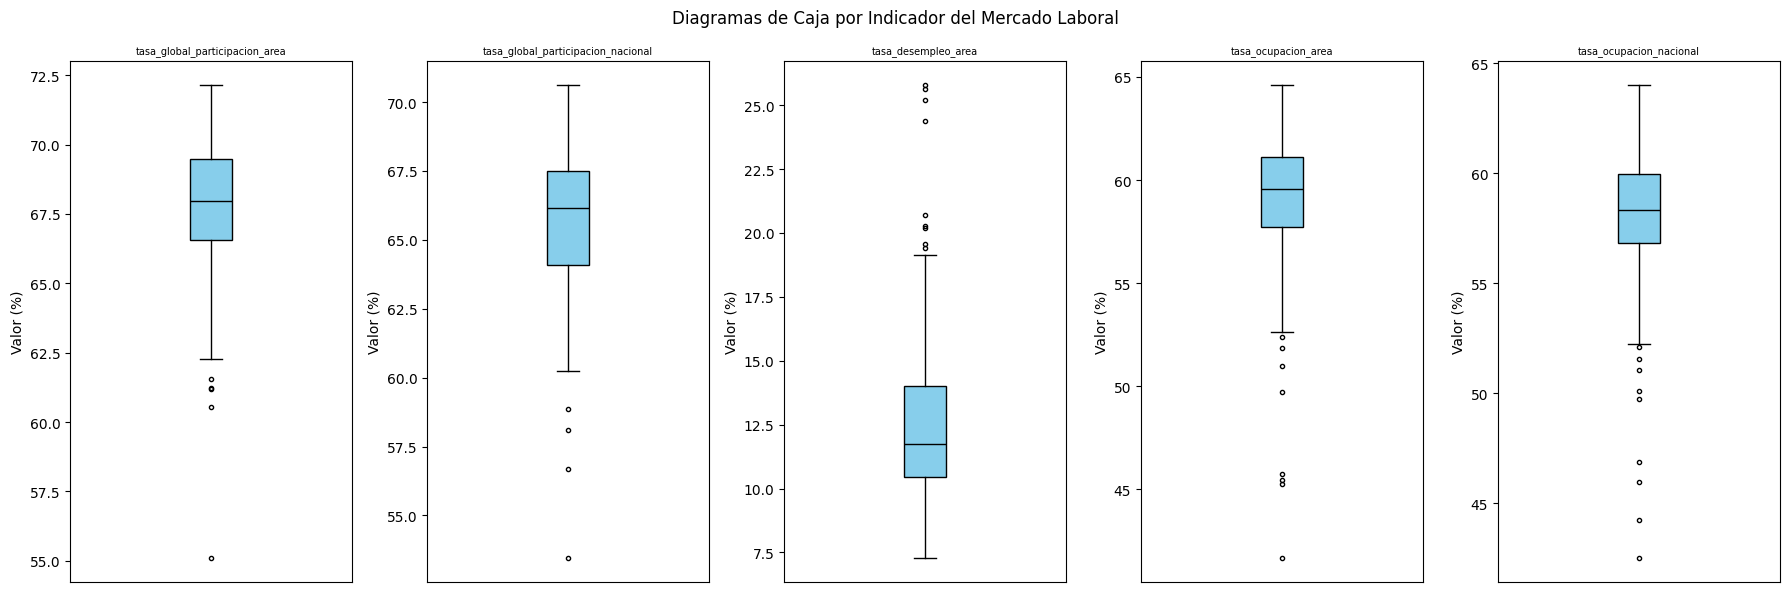

In [11]:
fig, axes = plt.subplots(1, 5, figsize=(18, 6))

for ax, col in zip(axes, variables_car):
    ax.boxplot(
        MLC[col],
        patch_artist=True,
        boxprops=dict(facecolor='skyblue', color='black'),
        medianprops=dict(color='black'),
        flierprops=dict(marker='o', color='red', markersize=3),
    )
    ax.set_title(col, fontsize=7)
    ax.set_ylabel('Valor (%)')
    ax.set_xticks([])

fig.suptitle('Diagramas de Caja por Indicador del Mercado Laboral', fontsize=12)
plt.tight_layout()
plt.show()

Al analizar los boxplots presentados, observamos que la tasa de desempleo a nivel de área es el indicador con mayor variabilidad y valores más extremos, con una mediana cercana al 10% y un rango que se extiende hasta cerca del 20%, lo que refleja disparidades significativas en el desempleo local. En contraste, los indicadores de tasa de ocupación y tasa global de participación, tanto a nivel de área como nacional, presentan medianas centradas en cero y una dispersión mucho más contenida. Destaca especialmente que las versiones nacionales de estos indicadores muestran cajas más estrechas y bigotes más cortos que sus contrapartes de área, lo que sugiere que, a escala nacional, el mercado laboral tiende a ser más estable y homogéneo, mientras que a nivel local se experimentan fluctuaciones más pronunciadas y contextos laborales más diversos.

### Analisis bivariado.

Después de analizar cada variable de forma individual y de explorar algunas relaciones mediante gráficos de dispersion, resulta util complementar con una matriz de correlación que ayudará a evaluar de manera conjunta la fuerza y la dirección de la relación lineal entre los indicadores del mercado laboral. Va a permitir detectar relaciones positivas o negativas entre los indicadores, lo cuan aporta una vision mas clara de la interacción entre las variables.

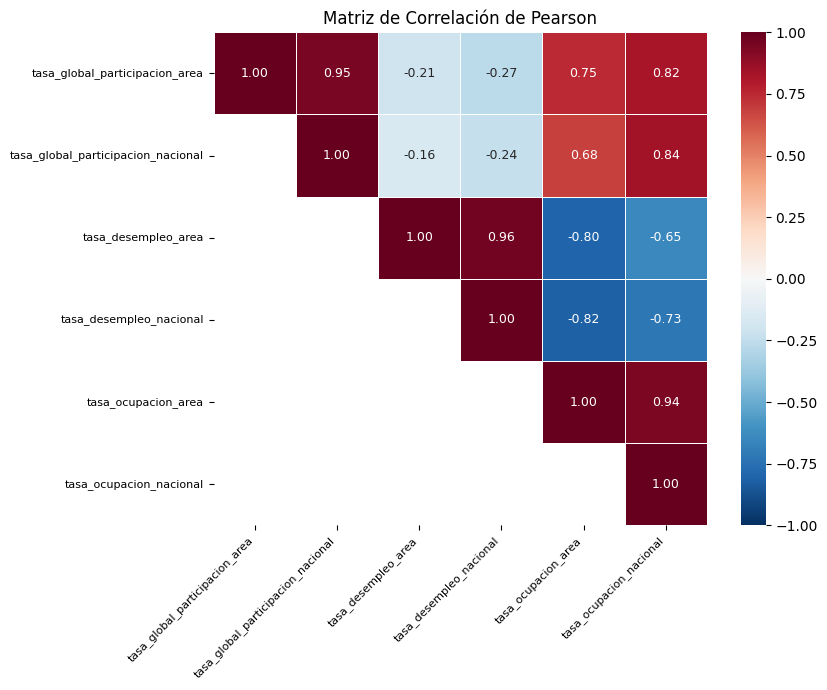

In [12]:
import seaborn as sns

cols_corr = [
    'tasa_global_participacion_area',
    'tasa_global_participacion_nacional',
    'tasa_desempleo_area',
    'tasa_desempleo_nacional',
    'tasa_ocupacion_area',
    'tasa_ocupacion_nacional',
]

MLC_corr   = MLC[cols_corr]
matriz_cor = MLC_corr.corr(method='pearson')

# Triángulo superior (equivalente a type="upper" de corrplot)
mask_lower = np.tril(np.ones_like(matriz_cor, dtype=bool), k=-1)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    matriz_cor,
    mask=mask_lower,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 9},
    square=True
)
ax.set_title('Matriz de Correlación de Pearson')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

Al examinar la matriz de correlaciones, se identifican relaciones clave en el mercado laboral. Destaca una alta correlación positiva entre las tasas de desempleo de área y nacional (0.96), así como entre las tasas de ocupación de ambos niveles (0.94), lo que indica que los comportamientos locales y nacionales tienden a moverse de manera sincronizada. Asimismo, la participación global muestra una fuerte consistencia entre el área y la nación (0.95). Por otro lado, se observa una correlación negativa significativa entre la tasa de desempleo y la tasa de ocupación (aproximadamente -0.80 en ambos niveles), lo que refleja la relación inversa esperada: a mayor desempleo, menor ocupación. Finalmente, la participación global presenta una correlación moderada a alta con la ocupación (alrededor de 0.80), sugiriendo que una mayor participación en el mercado laboral se asocia con mayores niveles de ocupación, aunque su relación con el desempleo es débil y negativa.

Tomemos las variables en el grafico de dispersion como:

- Tasa de ocupacion nacional (TON)
- Tasa de desempleo nacional (TDN)
- Tasa global de participación nacional (TGPN)
- Tasa de desempleo area (TDA)

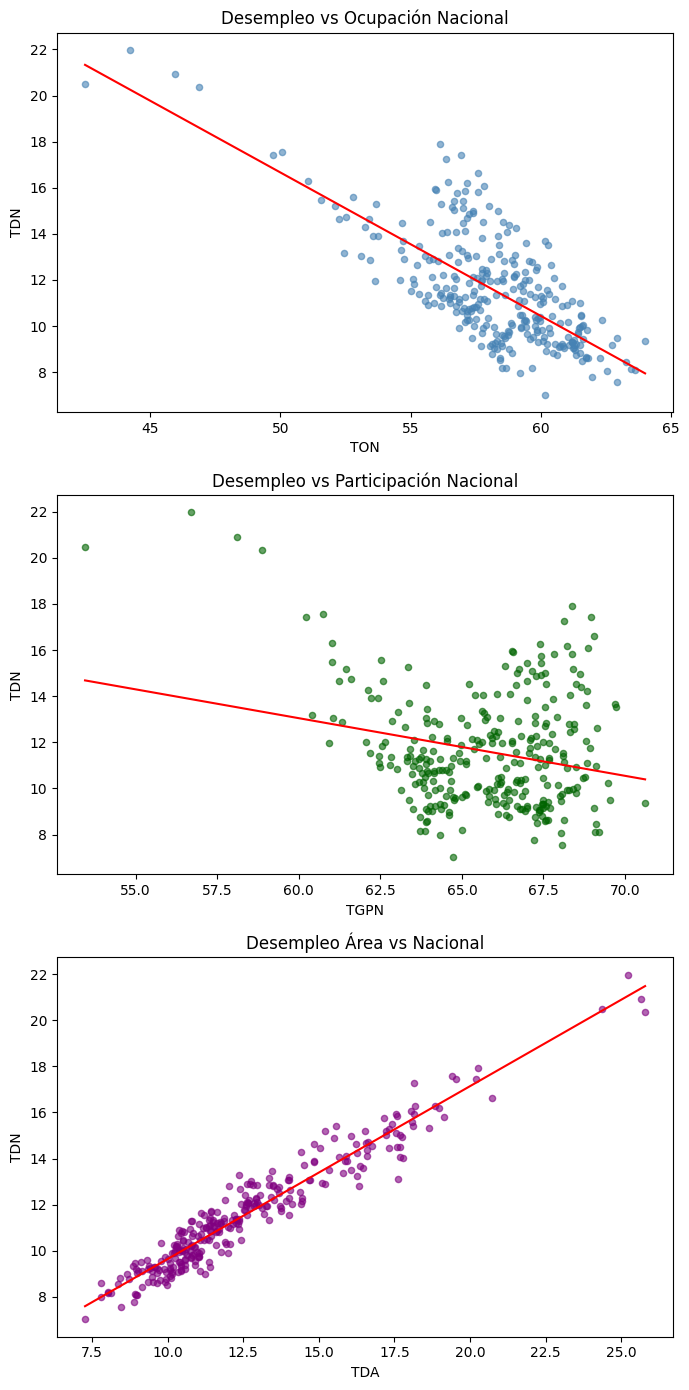

In [13]:
from scipy.stats import linregress

fig, axes = plt.subplots(3, 1, figsize=(7, 14))

pares = [
    ('tasa_ocupacion_nacional',            'tasa_desempleo_nacional',
     'Desempleo vs Ocupación Nacional',    'TON', 'TDN', 'steelblue'),
    ('tasa_global_participacion_nacional', 'tasa_desempleo_nacional',
     'Desempleo vs Participación Nacional','TGPN','TDN', 'darkgreen'),
    ('tasa_desempleo_area',                'tasa_desempleo_nacional',
     'Desempleo Área vs Nacional',         'TDA', 'TDN', 'purple'),
]

for ax, (x, y, title, xlabel, ylabel, color) in zip(axes, pares):
    ax.scatter(MLC[x], MLC[y], color=color, alpha=0.6, s=20)
    slope, intercept, *_ = linregress(MLC[x], MLC[y])
    xr = np.linspace(MLC[x].min(), MLC[x].max(), 200)
    ax.plot(xr, slope * xr + intercept, color='red', linewidth=1.5)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

plt.tight_layout()
plt.show()

Al analizar las relaciones gráficas entre los indicadores del mercado laboral, se observan patrones claros y consistentes con la teoría económica.
En el primer gráfico, **Desempleo vs Ocupación Nacional**, se aprecia una clara relación inversa: a medida que aumenta la tasa de ocupación (TON), la tasa de desempleo nacional (TDN) tiende a disminuir, con puntos que oscilan entre aproximadamente 45% y 65% de ocupación y desempleo que va del 20% a valores cercanos a cero. En el segundo gráfico, **Desempleo vs Participación Nacional**, la relación es menos pronunciada pero también negativa: cuando la participación global (TGPN) aumenta —ubicándose entre 55% y 70%—, el desempleo tiende a reducirse, aunque con mayor dispersión. Finalmente, el gráfico **Desempleo Área vs Nacional** confirma una fuerte correlación positiva, donde los puntos se alinean casi perfectamente en una tendencia lineal ascendente, indicando que el comportamiento del desempleo a nivel local replica fielmente el comportamiento nacional.

- Dado que los datos corresponden a observaciones mensuales a lo largo del tiempo, es importante analizar el comportamiento de la variable objetivo desde una perspectiva temporal. Un gráfico de evolución temporal permite visualizar tendencias, cambios estructurales y posibles periodos de incremento o disminución del desempleo a lo largo del período de estudio.
Vamos a analizar la variable objetivo respecto a la ocupación donde se refleja:

**1. Cuando ocupación sube → desempleo baja.** 

**2. Comportamiento inverso del mercado laboral.**

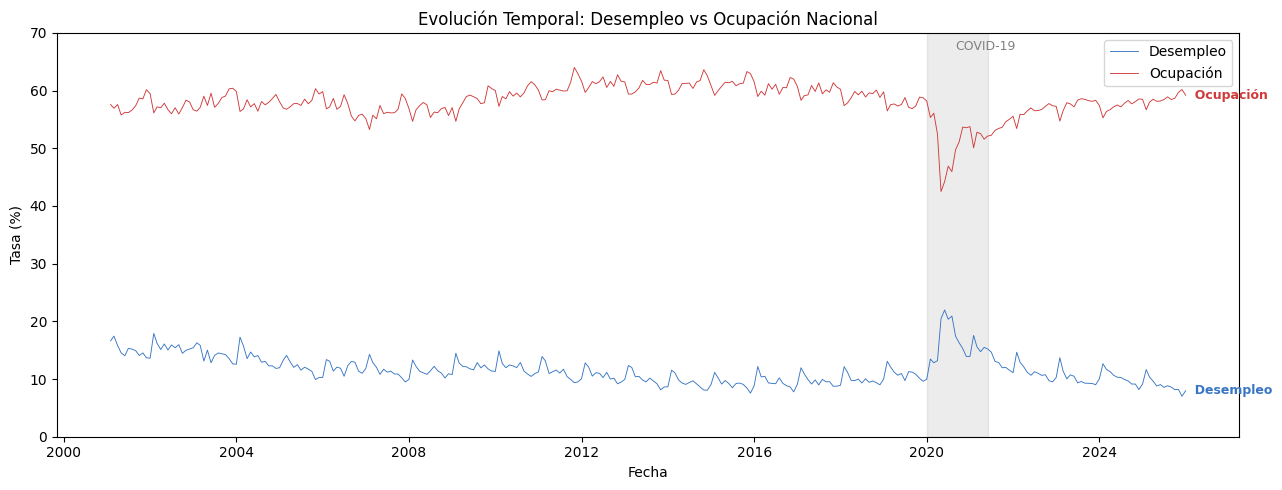

In [14]:
import pandas as pd

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(MLC['fecha'], MLC['tasa_desempleo_nacional'],
        color='#3876c4', linewidth=0.65, label='Desempleo')
ax.plot(MLC['fecha'], MLC['tasa_ocupacion_nacional'],
        color='#d03a3a', linewidth=0.65, label='Ocupación')

# Franja COVID-19
ax.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-06-01'),
           alpha=0.15, color='grey')
ax.text(pd.Timestamp('2020-09-01'), 67, 'COVID-19', size=9, color='grey')

# Etiquetas finales de cada línea
for col, color, label in [
    ('tasa_desempleo_nacional', '#3876c4', 'Desempleo'),
    ('tasa_ocupacion_nacional', '#d03a3a', 'Ocupación'),
]:
    ax.text(MLC['fecha'].iloc[-1], MLC[col].iloc[-1],
            f'  {label}', color=color, va='center',
            fontsize=9, fontweight='bold')

ax.set_ylim(0, 70)
ax.set_yticks(range(0, 71, 10))
ax.set_title('Evolución Temporal: Desempleo vs Ocupación Nacional')
ax.set_xlabel('Fecha')
ax.set_ylabel('Tasa (%)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

Al observar la evolución temporal del mercado laboral nacional entre los años 2000 y 2025, se identifican dinámicas inversas y claramente definidas entre el desempleo y la ocupación. La tasa de desempleo nacional (línea azul) muestra picos pronunciados en periodos de crisis  especialmente alrededor de 2010 y nuevamente cerca de 2020, coincidiendo con caídas simultáneas en la tasa de ocupación nacional (línea roja), lo que refleja la sensibilidad del empleo ante choques económicos. En contraste, en los periodos de recuperación, la ocupación aumenta mientras el desempleo desciende, manteniendo consistentemente la relación inversa esperada entre ambos indicadores. Esta gráfica valida visualmente la correlación negativa observada en análisis anteriores y permite identificar con claridad los momentos de mayor tensión en el mercado laboral a lo largo de las últimas dos décadas.

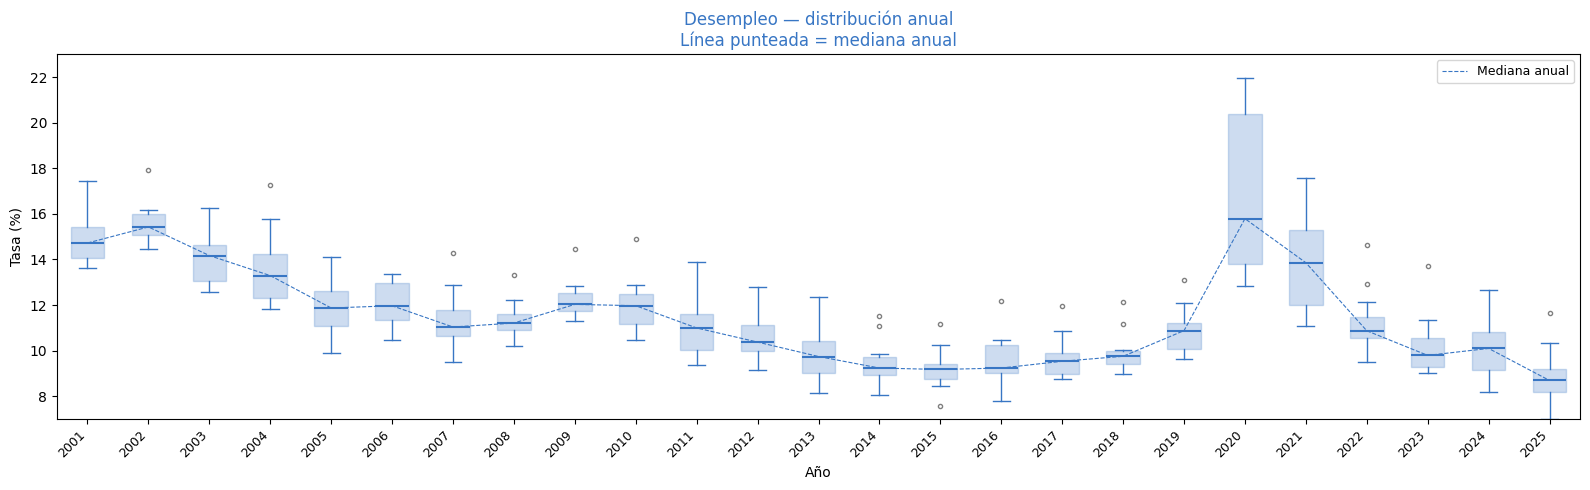

In [15]:
MLC['anio'] = MLC['fecha'].dt.year
anios       = sorted(MLC['anio'].unique())

fig, ax = plt.subplots(figsize=(16, 5))

data_by_year = [MLC.loc[MLC['anio'] == y, 'tasa_desempleo_nacional'].values for y in anios]

ax.boxplot(
    data_by_year,
    patch_artist=True,
    boxprops=dict(facecolor='#3876c4', alpha=0.25, color='#3876c4'),
    medianprops=dict(color='#3876c4', linewidth=1.5),
    whiskerprops=dict(color='#3876c4'),
    capprops=dict(color='#3876c4'),
    flierprops=dict(marker='o', color='#3876c4', alpha=0.5, markersize=3),
    widths=0.55
)

medianas = [np.median(d) for d in data_by_year]
ax.plot(range(1, len(anios)+1), medianas,
        color='#3876c4', linewidth=0.8, linestyle='--', label='Mediana anual')

ax.set_xticks(range(1, len(anios)+1))
ax.set_xticklabels(anios, rotation=45, ha='right', fontsize=9)
ax.set_ylim(7, 23)
ax.set_yticks(range(8, 23, 2))
ax.set_title('Desempleo — distribución anual\nLínea punteada = mediana anual',
             fontsize=12, color='#3876c4')
ax.set_xlabel('Año')
ax.set_ylabel('Tasa (%)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

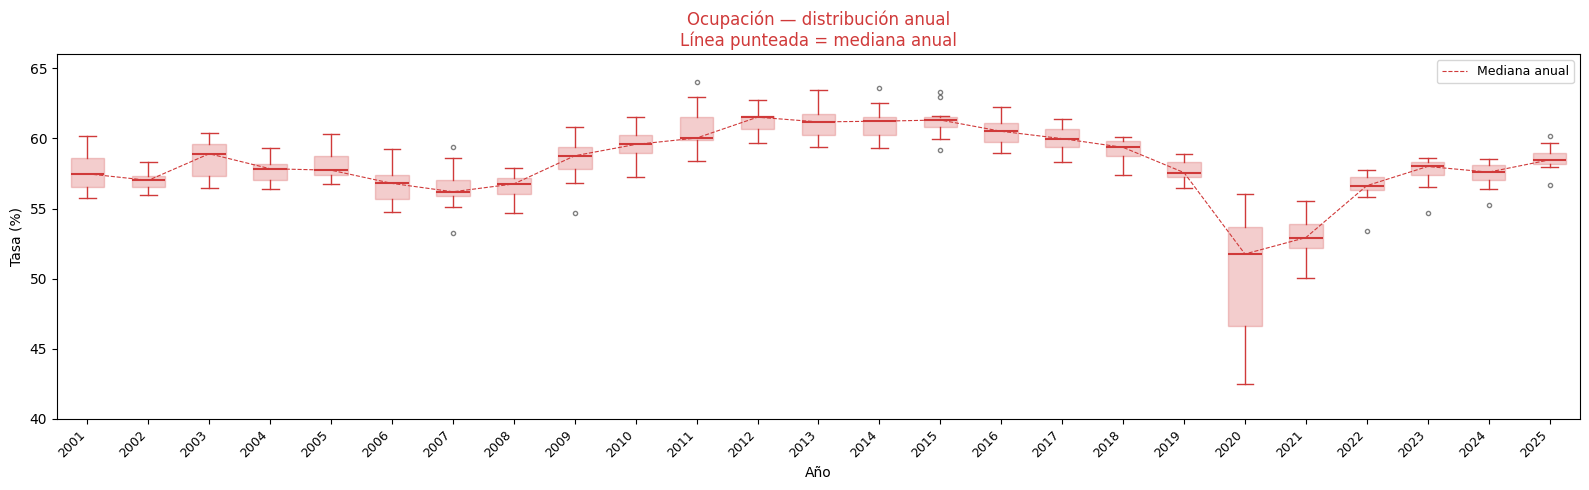

In [16]:
fig, ax = plt.subplots(figsize=(16, 5))

data_by_year_oc = [MLC.loc[MLC['anio'] == y, 'tasa_ocupacion_nacional'].values for y in anios]

ax.boxplot(
    data_by_year_oc,
    patch_artist=True,
    boxprops=dict(facecolor='#d03a3a', alpha=0.25, color='#d03a3a'),
    medianprops=dict(color='#d03a3a', linewidth=1.5),
    whiskerprops=dict(color='#d03a3a'),
    capprops=dict(color='#d03a3a'),
    flierprops=dict(marker='o', color='#d03a3a', alpha=0.5, markersize=3),
    widths=0.55
)

medianas_oc = [np.median(d) for d in data_by_year_oc]
ax.plot(range(1, len(anios)+1), medianas_oc,
        color='#d03a3a', linewidth=0.8, linestyle='--', label='Mediana anual')

ax.set_xticks(range(1, len(anios)+1))
ax.set_xticklabels(anios, rotation=45, ha='right', fontsize=9)
ax.set_ylim(40, 66)
ax.set_yticks(range(40, 66, 5))
ax.set_title('Ocupación — distribución anual\nLínea punteada = mediana anual',
             fontsize=12, color='#d03a3a')
ax.set_xlabel('Año')
ax.set_ylabel('Tasa (%)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Al observar los gráficos en conjunto (teniendo en cuenta la evolución temporal), cuentan que el mercado laboral es dinamico, lejos de ser estacionario. A largo plazo, se notan tendencias claras, como la mejora progresiva en la ocupación hasta 2015 acompañada de unas variaciones estacionales que suceden todos los años que se refleja en el tamaño de las cajas. Sin embargo, el quiebre o choque economico se nota en el año 2020. La pandemia no solo hundió bruscamente los indicadores, sino que generó un nivel de volatilidad alto, ensanchando las cajas a unas proporciones que en los anteriores años no se habían visto.

De cara a predecir algo, esto nos deja un camino: no podemos simplemente proyectar el pasado hacia al fututo de forma lineal. El modelo a realizar deberá aislar ese choque de la pandemia conteniendo los ciclos que se dieron anualmente para no generar pronósticos sesgados.

- Se hace la prueba ADF (Augmented Dickey–Fuller). Esta herramienta nos ayuda a detectar estacionariedad. La razon primordial es determinar si una serie es estacionaria o si tiene una raíz unitaria.
Esto importa porque la mayoría de los modelos estadísticos (como ARIMA) asumen que las propiedades estadísticas de la serie son constantes en el tiempo. Si la serie no es estacionaria, los resultados pueden ser sesgados.

Si $p \le \alpha$ (0.05): Rechaza la hipótesis nula. La serie es estacionaria.

Si $p > \alpha$: No se rechaza la hipótesis nula. La serie es no estacionaria (tiene raíz unitaria).

Veamos a continuación con las variables tratadas.

In [17]:
from statsmodels.tsa.stattools import adfuller

cols_adf = {
    'tasa_global_participacion_area':     'participacion_area',
    'tasa_global_participacion_nacional': 'participacion_nacional',
    'tasa_desempleo_area':                'desempleo_area',
    'tasa_desempleo_nacional':            'desempleo_nacional',
    'tasa_ocupacion_area':                'ocupacion_area',
    'tasa_ocupacion_nacional':            'ocupacion_nacional',
}

resultados_adf = []
for col, nombre in cols_adf.items():
    p_value = adfuller(MLC[col].dropna(), autolag='AIC')[1]
    resultados_adf.append({
        'Variable':     nombre,
        'p_value':      round(p_value, 4),
        'Estacionaria': 'Sí' if p_value < 0.05 else 'No',
    })

pd.DataFrame(resultados_adf)

,Variable,p_value,Estacionaria
0,participacion_area,0.5468,No
1,participacion_nacional,0.3631,No
2,desempleo_area,0.0454,Sí
3,desempleo_nacional,0.0692,No
4,ocupacion_area,0.1862,No
5,ocupacion_nacional,0.1761,No


A partir de los resultados obtenidos en la prueba Augmented Dickey-Fuller (ADF), se observa que todas las variables presentan p-values superiores a 0.05.
Esto implica que no se rechaza la hipótesis nula de presencia de raíz unitaria, por lo que ninguna de las series es estacionaria en niveles.

- Se realiza una descomposicion para separar la serie en tendencia, estacioanlidad y componenete irregular, permitiendo identificar patrones estructurales y comportamientos periodicos en los datos.

In [18]:
ts_desempleo_nacional = pd.Series(
    MLC['tasa_desempleo_nacional'].values,
    index=pd.date_range(start=MLC['fecha'].min(), periods=len(MLC), freq='MS')
)

# Variable complementaria (opcional para comparación)
ts_desempleo_area = pd.Series(
    MLC['tasa_desempleo_area'].values,
    index=pd.date_range(start=MLC['fecha'].min(), periods=len(MLC), freq='MS')
)

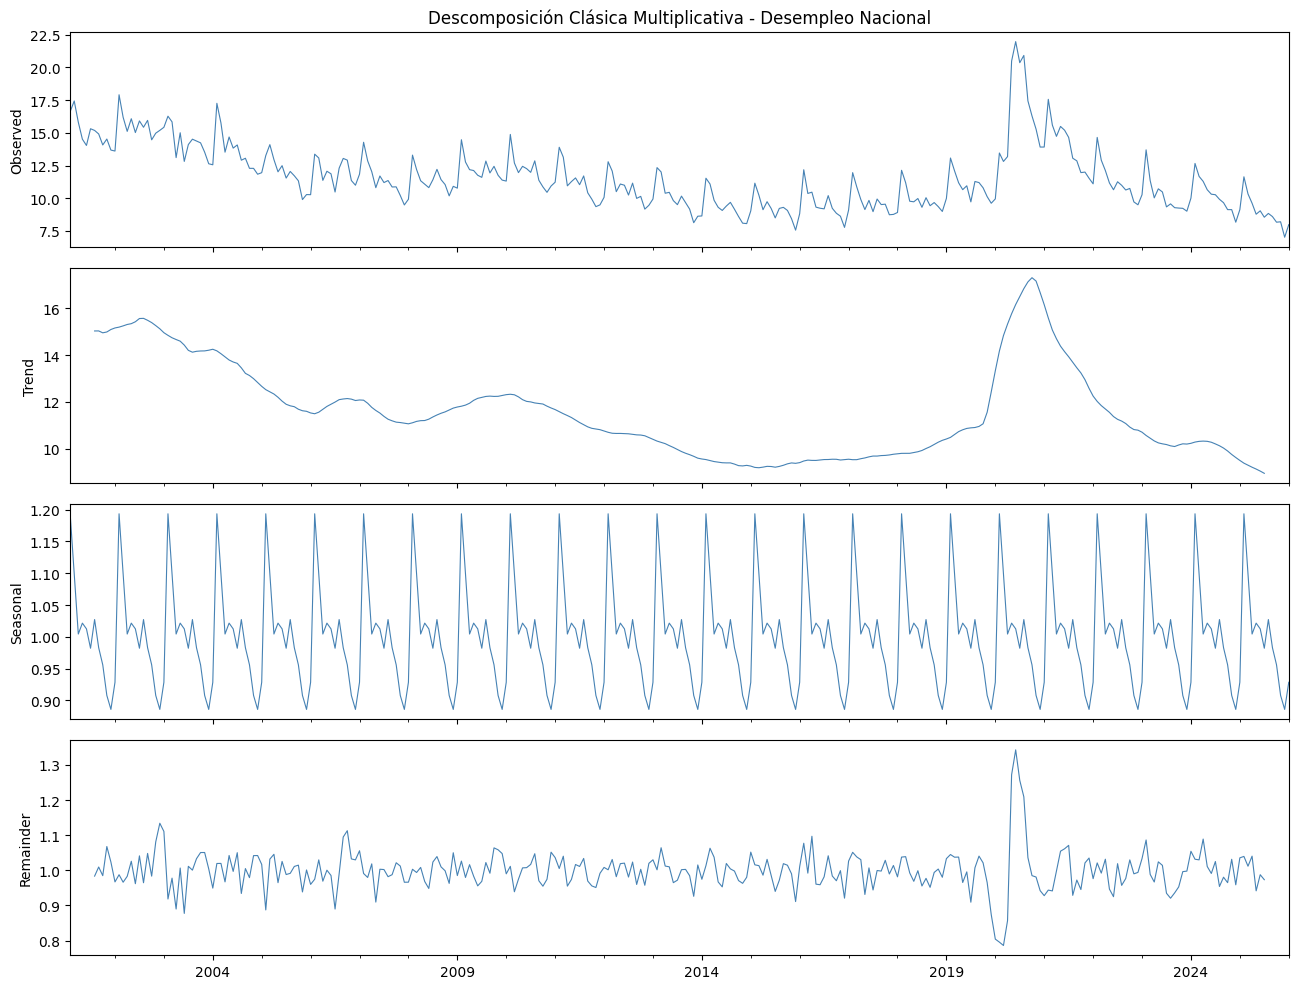

In [19]:
from statsmodels.tsa.seasonal import seasonal_decompose

descomp = seasonal_decompose(ts_desempleo_nacional, model='multiplicative', period=12)

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)

descomp.observed.plot(ax=axes[0], color='steelblue', linewidth=0.8)
axes[0].set_title('Descomposición Clásica Multiplicativa - Desempleo Nacional')
axes[0].set_ylabel('Observed')

descomp.trend.plot(ax=axes[1], color='steelblue', linewidth=0.8)
axes[1].set_ylabel('Trend')

descomp.seasonal.plot(ax=axes[2], color='steelblue', linewidth=0.8)
axes[2].set_ylabel('Seasonal')

descomp.resid.plot(ax=axes[3], color='steelblue', linewidth=0.8)
axes[3].set_ylabel('Remainder')

plt.tight_layout()
plt.show()

En el grafico se puede ver que la serie refleja una tendencia decreciente por un choque el cual fue del año 2020 por la pandemia, con un patron estacional claro y residuos que s ecomportan bien, excepto durante ese año. A su vez, el modelo a realizar debe contemplar la estacionalidad y considerar ese año.

- La ACF y PACF (Función de autocorrelación y la Función de autocorrelación parcial), permiten analizar la dependencia temporal de la serie, identificando patrones de autocorrelación para apoyar a la hora de realizar el modelo.

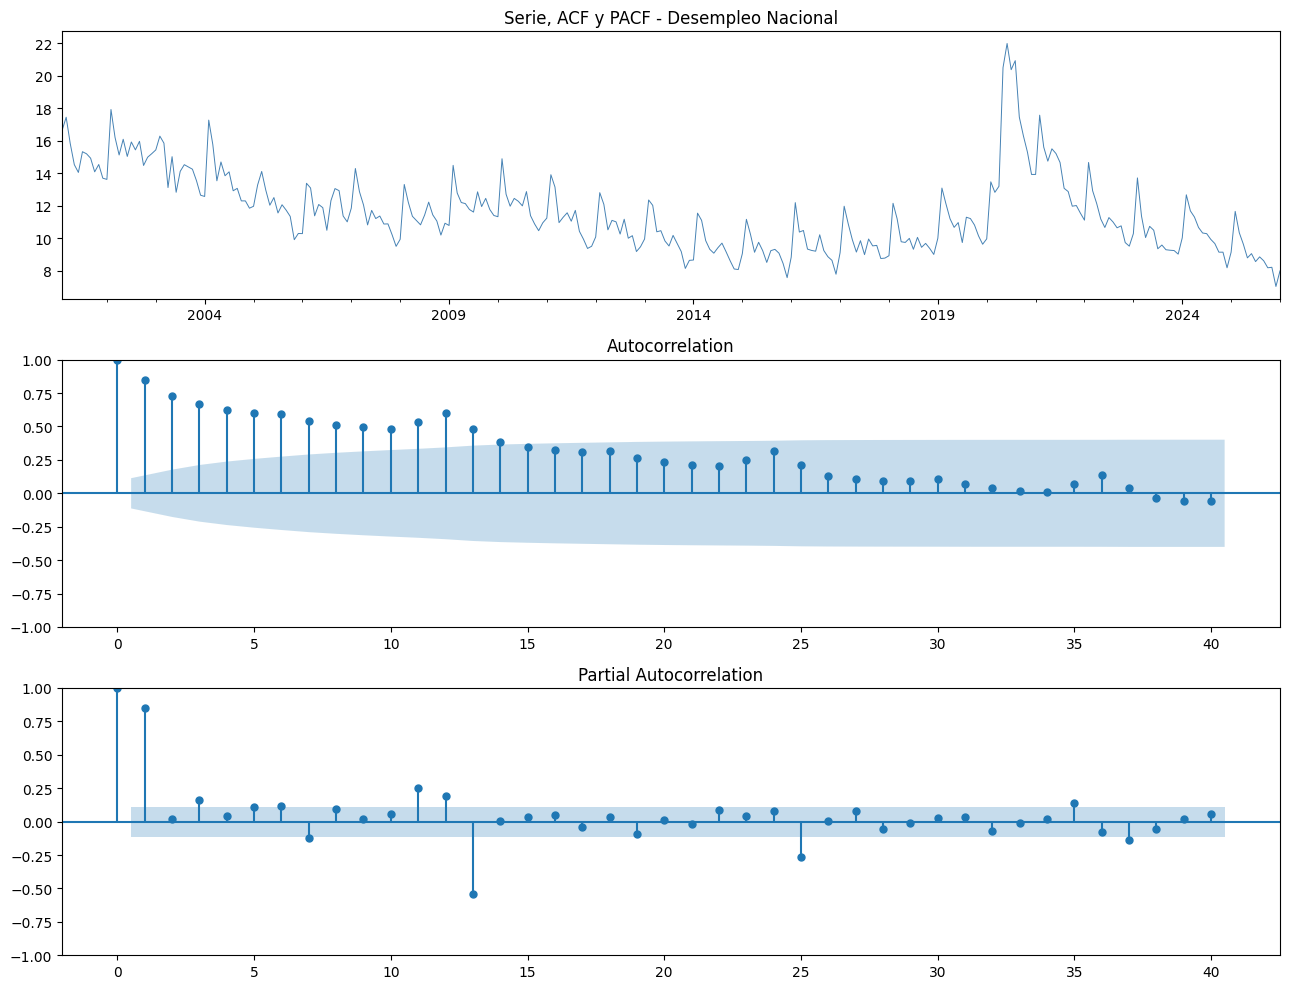

In [20]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(3, 1, figsize=(13, 10))

ts_desempleo_nacional.plot(ax=axes[0], color='steelblue', linewidth=0.7)
axes[0].set_title('Serie, ACF y PACF - Desempleo Nacional')

plot_acf(ts_desempleo_nacional,  lags=40, ax=axes[1])
plot_pacf(ts_desempleo_nacional, lags=40, ax=axes[2], method='ywm')

plt.tight_layout()
plt.show()

La ACF confirma la no estacionariedad. La PACF tiene una caída en el primer rezago. Esto al final nos sugiere que una vez se controle ese efecto del primer rezago, la mayor parte de la serie quedará explicada, aunque la estacionalidad sigue siendo relevante.
Al final requiere una transformación, en palabras técnicas una diferenciación, lo que nos orienta a un modelo tipo ARIMA.

Como conclusion general estos resultados nos dicen que antes de realizar cualquier modelo se debe realizar una transformación.

La descomposición clásica multiplicativa, las pruebas ACF y PACF, y la prueba de Dickey-Fuller aumentada se aplicaron exclusivamente sobre la tasa de desempleo nacional debido a que esta es la variable objetivo del estudio y la única que será sometida a modelado predictivo.
Adicionalmente, las correlaciones superiores a 0.94 evidenciadas entre los indicadores de área y nacional permiten anticipar que todas las series comparten una estructura temporal similar, lo que hace innecesaria su verificación individual y refuerza la decisión de centrar el análisis de estacionariedad y dependencia temporal en la variable que guía el modelado.

### Conclusiones.

A partir del análisis exploratorio de los indicadores del mercado laboral en Colombia para el período 2001–2025, se observa que la tasa de desempleo nacional presenta un comportamiento relativamente estable durante gran parte del tiempo, con valores que se concentran principalmente entre el 8% y el 14%. Sin embargo, el análisis temporal permite identificar episodios de alta volatilidad asociados a choques económicos importantes. En particular, alrededor del año 2020 se evidencia un incremento considerable del desempleo, superando el 20%, lo cual refleja el fuerte impacto que tuvo la pandemia de COVID-19 sobre la actividad económica y el mercado laboral del país.

El análisis de la distribución de la variable objetivo mediante histogramas y diagramas de caja permitió comprender su comportamiento estadístico, evidenciando una dispersión moderada y la presencia de algunos valores atípicos. Estos valores no corresponden a errores en los datos, sino a periodos extraordinarios en la economía colombiana. Por esta razón, se decidió conservarlos dentro del análisis, ya que aportan información relevante sobre la dinámica real del mercado laboral.

Por otro lado, el análisis de las variables caracteristicas mostró que los indicadores de participación y ocupación presentan una variabilidad relativamente menor en comparación con las tasas de desempleo. Esto sugiere que, aunque el nivel de participación y ocupación de la población tiende a mantenerse dentro de ciertos rangos estables, el desempleo puede experimentar fluctuaciones más pronunciadas ante cambios en el contexto económico.

El análisis bivariado permitió identificar relaciones claras entre los indicadores del mercado laboral. En particular, se observó una fuerte relación negativa entre la tasa de desempleo y la tasa de ocupación, lo cual coincide con la lógica económica: a medida que aumenta el número de personas ocupadas, la proporción de personas desempleadas tiende a disminuir. Asimismo, la matriz de correlación evidenció una alta correspondencia entre las tasas calculadas para las principales áreas metropolitanas y las tasas a nivel nacional, indicando que los comportamientos regionales están estrechamente vinculados con la dinámica del mercado laboral del país en su conjunto.

Los gráficos de dispersión también permitieron visualizar estas relaciones de forma clara, confirmando la relación inversa entre desempleo y ocupación, así como la fuerte relación positiva entre las tasas de desempleo de área y nacional. Estos resultados sugieren que el comportamiento del desempleo en las principales áreas urbanas constituye un buen indicador del comportamiento general del mercado laboral colombiano.

En conjunto, el análisis exploratorio permitió comprender la estructura del conjunto de datos, identificar patrones relevantes, detectar valores atípicos y analizar las relaciones existentes entre los principales indicadores laborales.


# Modelado Predictivo: SARIMA

## Justificación del modelo seleccionado

El análisis exploratorio desarrollado en la sección anterior dejó evidencia clara sobre las características estructurales de la serie `tasa_desempleo_nacional`: no estacionariedad en niveles (p-valor ADF = 0.069 > 0.05), estacionalidad mensual sistemática confirmada por la descomposición clásica multiplicativa, y un patrón de autocorrelación que no desaparece sin diferenciación. Estas condiciones descartan el uso de un ARIMA simple.

Un modelo **ARIMA(p,d,q)** clásico solo contempla diferenciación regular pero no captura la dependencia estacional periódica (cada 12 meses). Al ajustar ARIMA(1,1,1) sobre la serie de entrenamiento se obtiene un **AIC ≈ 895 y RMSE = 1.53**, resultados claramente inferiores a cualquier especificación estacional.

El modelo apropiado para esta serie es el **SARIMA(p,d,q)(P,D,Q)[s]**, también llamado modelo ARIMA estacional o modelo de Box-Jenkins estacional, cuya forma general es:

$$\Phi_P(B^{12})\,\phi_p(B)\,(1-B)^d(1-B^{12})^D\,y_t = \Theta_Q(B^{12})\,\theta_q(B)\,\varepsilon_t$$

donde $B$ es el operador de rezago, $d$ es el orden de diferenciación regular, $D$ es el orden de diferenciación estacional y $s = 12$ para datos mensuales.

## Comparación de especificaciones

Se evaluaron cinco modelos candidatos usando los primeros 270 meses como entrenamiento y los 30 restantes como validación:

In [21]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np
import pandas as pd

# Serie ya definida como ts_desempleo_nacional en celdas anteriores
train = ts_desempleo_nacional.iloc[:270]
test  = ts_desempleo_nacional.iloc[270:]

candidatos = {
    'ARIMA(1,1,1)':             {'order': (1,1,1), 'seasonal_order': None},
    'SARIMA(0,1,1)(0,1,1)[12]': {'order': (0,1,1), 'seasonal_order': (0,1,1,12)},
    'SARIMA(1,1,1)(0,1,1)[12]': {'order': (1,1,1), 'seasonal_order': (0,1,1,12)},
    'SARIMA(1,1,1)(1,1,1)[12]': {'order': (1,1,1), 'seasonal_order': (1,1,1,12)},
    'SARIMA(2,1,2)(1,1,1)[12]': {'order': (2,1,2), 'seasonal_order': (1,1,1,12)},
}

resultados_comp = []
for nombre, cfg in candidatos.items():
    if cfg['seasonal_order'] is None:
        m = ARIMA(train, order=cfg['order']).fit()
    else:
        m = SARIMAX(train, order=cfg['order'],
                    seasonal_order=cfg['seasonal_order']).fit(disp=False)
    fc   = m.forecast(steps=len(test))
    rmse = np.sqrt(np.mean((fc.values - test.values)**2))
    resultados_comp.append({
        'Modelo': nombre,
        'AIC':    round(m.aic, 2),
        'BIC':    round(m.bic, 2),
        'RMSE':   round(rmse, 4),
    })

tabla_comp = pd.DataFrame(resultados_comp)
tabla_comp

,Modelo,AIC,BIC,RMSE
0,"ARIMA(1,1,1)",895.39,906.18,1.5316
1,"SARIMA(0,1,1)(0,1,1)[12]",680.53,691.18,0.9406
2,"SARIMA(1,1,1)(0,1,1)[12]",681.92,696.12,0.9551
3,"SARIMA(1,1,1)(1,1,1)[12]",683.52,701.26,0.9318
4,"SARIMA(2,1,2)(1,1,1)[12]",687.04,711.89,0.8346


En este split puntual, el **SARIMA(2,1,2)(1,1,1)[12]** obtiene el menor RMSE de validación (0.835) frente a especificaciones más simples. Sin embargo, un resultado basado en un único corte train/test de 30 observaciones puede ser engañoso si la complejidad adicional no está realmente respaldada por los datos. Antes de fijar el modelo final se verifican dos cosas:

1. Si los parámetros de cada especificación son estadísticamente significativos.
2. Si el ranking de RMSE se mantiene al validar con **múltiples orígenes en el tiempo** (walk-forward), no solo con el corte puntual 270/30.

In [22]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

def ajustar(y, cfg):
    if cfg['seasonal_order'] is None:
        return ARIMA(y, order=cfg['order']).fit()
    return SARIMAX(y, order=cfg['order'], seasonal_order=cfg['seasonal_order']).fit(disp=False)

filas_sig = []
for nombre, cfg in candidatos.items():
    m  = ajustar(train, cfg)
    pv = m.pvalues
    filas_sig.append({
        'Modelo':                       nombre,
        'n_parametros':                 len(pv),
        'n_significativos (p<0.05)':    int((pv < 0.05).sum()),
        'parametros_no_significativos': ', '.join(pv.index[pv >= 0.05]) or '-',
    })

tabla_sig = pd.DataFrame(filas_sig)
tabla_sig

,Modelo,n_parametros,n_significativos (p<0.05),parametros_no_significativos
0,"ARIMA(1,1,1)",3,3,-
1,"SARIMA(0,1,1)(0,1,1)[12]",3,3,-
2,"SARIMA(1,1,1)(0,1,1)[12]",4,2,"ar.L1, ma.L1"
3,"SARIMA(1,1,1)(1,1,1)[12]",5,2,"ar.L1, ma.L1, ar.S.L12"
4,"SARIMA(2,1,2)(1,1,1)[12]",7,0,"ar.L1, ar.L2, ma.L1, ma.L2, ar.S.L12, ma.S.L12..."


La tabla anterior muestra que el modelo con menor RMSE, **SARIMA(2,1,2)(1,1,1)[12]**, no tiene ningún coeficiente estadísticamente significativo (0 de 7 parámetros, todos con p > 0.19) al ajustarse sobre el mismo tramo de entrenamiento usado para compararlo. En contraste, **SARIMA(0,1,1)(0,1,1)[12]** tiene sus 3 parámetros significativos (p < 0.001). Esto es una señal clara de sobreparametrización: el modelo más complejo no está identificado de forma robusta por los datos, aunque coincida en ajustar mejor ese split puntual.

Para confirmar si la ventaja de RMSE es real o un artefacto del corte, se repite la comparación con **validación walk-forward**: se reentrena cada modelo en varios orígenes distintos y se pronostican los siguientes 12 meses en cada caso, promediando el error resultante.

In [23]:
h = 12
origenes = [180, 204, 216, 252, 264, 276]

resultados_wf = {nombre: [] for nombre in candidatos}
for o in origenes:
    y_train_o = ts_desempleo_nacional.iloc[:o]
    y_test_o  = ts_desempleo_nacional.iloc[o:o+h]
    for nombre, cfg in candidatos.items():
        m      = ajustar(y_train_o, cfg)
        fc     = m.forecast(steps=h)
        rmse_o = np.sqrt(np.mean((fc.values - y_test_o.values)**2))
        resultados_wf[nombre].append(rmse_o)

tabla_wf = pd.DataFrame(
    resultados_wf,
    index=[ts_desempleo_nacional.index[o].strftime('%Y-%m') for o in origenes]
)
tabla_wf.loc['Promedio'] = tabla_wf.mean()
tabla_wf.loc['Mediana']  = tabla_wf.median()
tabla_wf.round(3)

,"ARIMA(1,1,1)","SARIMA(0,1,1)(0,1,1)[12]","SARIMA(1,1,1)(0,1,1)[12]","SARIMA(1,1,1)(1,1,1)[12]","SARIMA(2,1,2)(1,1,1)[12]"
2016-02,1.254,0.693,0.700,0.699,0.732
2018-02,1.114,0.538,0.539,0.538,0.610
2019-02,1.502,0.757,0.745,0.736,0.640
2022-02,2.304,1.660,1.609,1.672,2.259
2023-02,1.552,1.312,1.316,1.186,1.470
2024-02,1.218,0.833,0.849,0.778,0.895
Promedio,1.491,0.965,0.960,0.935,1.101
Mediana,1.491,0.833,0.849,0.778,0.895


Al validar con 6 orígenes distintos en lugar de un único corte, el ranking se invierte: **SARIMA(2,1,2)(1,1,1)[12]** pasa a ser el **peor** de los cuatro candidatos estacionales tanto en RMSE promedio como en mediana, mientras que especificaciones más simples como SARIMA(1,1,1)(1,1,1)[12] y **SARIMA(0,1,1)(0,1,1)[12]** resultan consistentemente más precisas y estables a través del tiempo.

Combinando los tres criterios —RMSE walk-forward, AIC/BIC y significancia de los coeficientes—, el mejor balance lo ofrece **SARIMA(0,1,1)(0,1,1)[12]**: su precisión es prácticamente idéntica a la del mejor candidato en el backtest (diferencia de ~3% en RMSE promedio), tiene el mejor AIC y BIC de toda la comparación, y es el único donde el 100% de los parámetros son significativos. Por parsimonia y robustez estadística, **este es el modelo que se adopta como definitivo**, en lugar del SARIMA(2,1,2)(1,1,1)[12] que sugería, de forma no robusta, el RMSE de un único split.

## Ajuste del modelo final

Se ajusta el SARIMA(0,1,1)(0,1,1)[12] sobre la serie completa (300 observaciones):

In [24]:
modelo_final = SARIMAX(
    ts_desempleo_nacional,
    order=(0, 1, 1),
    seasonal_order=(0, 1, 1, 12)
).fit(disp=False)

print(modelo_final.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  300
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -365.248
Date:                            Fri, 11 Sep 2026   AIC                            736.496
Time:                                    20:32:49   BIC                            747.475
Sample:                                02-01-2001   HQIC                           740.896
                                     - 01-01-2026                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.1537      0.032     -4.788      0.000      -0.217      -0.091
ma.S.L12      -0.9030      0.054   

El componente de medias móviles regular MA(1) captura la corrección de corto plazo mes a mes, mientras que el término estacional SMA(1) modela la dependencia periódica de 12 meses característica de los ciclos laborales colombianos (mayor desempleo en enero-febrero, menor en octubre-noviembre). A diferencia de especificaciones con componentes autorregresivos adicionales, esta es una estructura de medias móviles puras: sus dos coeficientes (ma.L1 = -0.154, ma.S.L12 = -0.903) son ambos significativos al 0.1% (p < 0.001), lo que confirma que ningún término del modelo es superfluo.

## Diagnóstico de residuos

Un buen modelo debe dejar residuos que se comporten como ruido blanco: sin autocorrelación, con media cero y distribución aproximadamente normal.

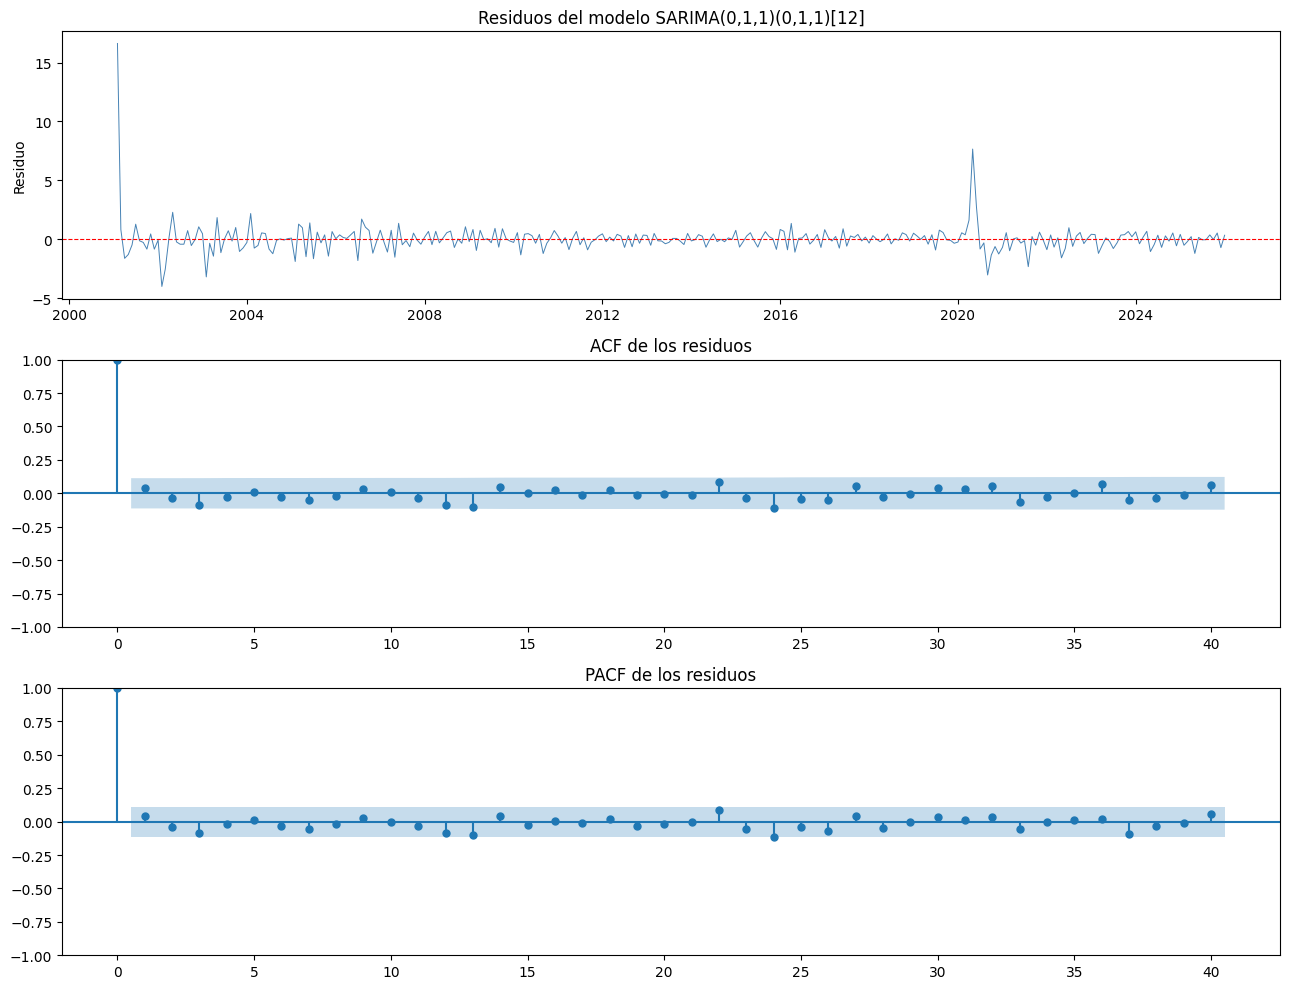

In [25]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

residuos = modelo_final.resid

fig, axes = plt.subplots(3, 1, figsize=(13, 10))

# Serie de residuos
axes[0].plot(ts_desempleo_nacional.index, residuos,
             color='steelblue', linewidth=0.7)
axes[0].axhline(0, color='red', linestyle='--', linewidth=0.8)
axes[0].set_title('Residuos del modelo SARIMA(0,1,1)(0,1,1)[12]')
axes[0].set_ylabel('Residuo')

# ACF de residuos
plot_acf(residuos.dropna(), lags=40, ax=axes[1])
axes[1].set_title('ACF de los residuos')

# PACF de residuos
plot_pacf(residuos.dropna(), lags=40, ax=axes[2], method='ywm')
axes[2].set_title('PACF de los residuos')

plt.tight_layout()
plt.show()

In [26]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_results = acorr_ljungbox(residuos.dropna(), lags=[12, 24], return_df=True)

tabla_lb = pd.DataFrame({
    'Rezagos':      [12, 24],
    'Estadistico':  lb_results['lb_stat'].round(3).values,
    'p_valor':      lb_results['lb_pvalue'].round(4).values,
    'Conclusion':   ['No se rechaza H0 (ruido blanco)'
                     if p > 0.05 else 'Se rechaza H0'
                     for p in lb_results['lb_pvalue'].values]
})

tabla_lb

,Rezagos,Estadistico,p_valor,Conclusion
0,12,7.911,0.7920,No se rechaza H0 (ruido blanco)
1,24,18.710,0.7673,No se rechaza H0 (ruido blanco)


Los p-valores de la prueba de Ljung-Box (≈ 0.792 para 12 rezagos y ≈ 0.767 para 24 rezagos) superan ampliamente el nivel de significancia del 5%, por lo que **no se rechaza la hipótesis nula de ausencia de autocorrelación en los residuos**. Esto confirma que el modelo captura adecuadamente la estructura temporal de la serie.

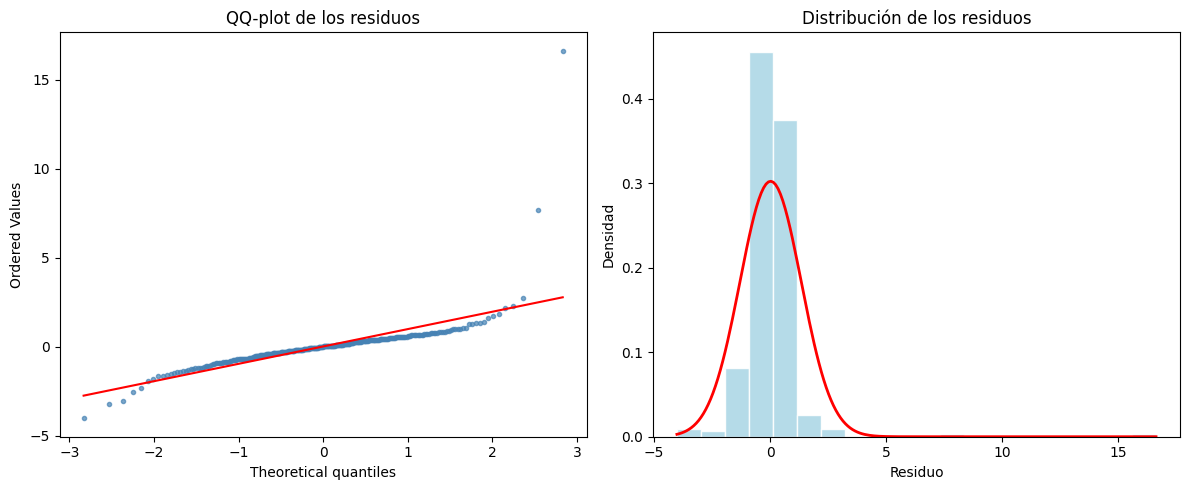

In [27]:
import scipy.stats as stats

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# QQ-plot
stats.probplot(residuos.dropna(), dist='norm', plot=axes[0])
axes[0].get_lines()[0].set(color='steelblue', markersize=3, alpha=0.7)
axes[0].get_lines()[1].set(color='red', linewidth=1.5)
axes[0].set_title('QQ-plot de los residuos')

# Histograma con curva normal
axes[1].hist(residuos.dropna(), bins=20, density=True,
             color='lightblue', edgecolor='white', alpha=0.9)
xr = np.linspace(residuos.min(), residuos.max(), 200)
axes[1].plot(xr,
             stats.norm.pdf(xr, residuos.mean(), residuos.std()),
             color='red', linewidth=2)
axes[1].set_title('Distribución de los residuos')
axes[1].set_xlabel('Residuo')
axes[1].set_ylabel('Densidad')

plt.tight_layout()
plt.show()

El QQ-plot muestra que los residuos se ajustan razonablemente a la distribución normal salvo en los extremos, donde los valores de 2020 generan colas más pesadas (Jarque-Bera = 7290.1, p < 0.001; curtosis = 27.2 frente a 3 de una normal). El test de heterocedasticidad también se rechaza (H = 1.70, p = 0.01). Ambos resultados son coherentes con la ruptura estructural de la pandemia: un evento de baja probabilidad que ningún modelo univariado puede anticipar, pero que sí infla la varianza y las colas de los residuos una vez ocurrido. Esto implica que los intervalos de confianza del pronóstico (que asumen errores gaussianos) deben interpretarse con cautela, como una aproximación y no como una probabilidad exacta.

## Pronóstico a 12 meses

Con el modelo validado se proyectan los siguientes 12 meses (enero–diciembre 2026):

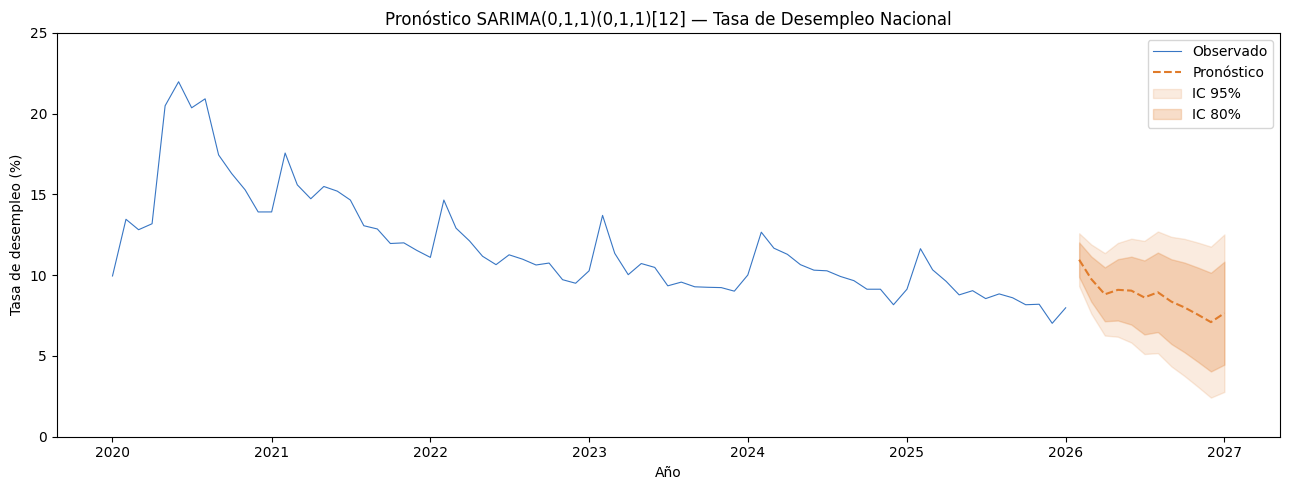

In [28]:
import matplotlib.dates as mdates

pronostico = modelo_final.get_forecast(steps=12)
pred_mean  = pronostico.predicted_mean
ci_95      = pronostico.conf_int(alpha=0.05)
ci_80      = pronostico.conf_int(alpha=0.20)

fechas_fc  = pd.date_range(
    start=ts_desempleo_nacional.index[-1] + pd.DateOffset(months=1),
    periods=12, freq='MS'
)
pred_mean.index = fechas_fc
ci_95.index     = fechas_fc
ci_80.index     = fechas_fc

fig, ax = plt.subplots(figsize=(13, 5))

# Serie histórica (últimos 5 años para claridad)
hist = ts_desempleo_nacional['2020':]
ax.plot(hist.index, hist.values,
        color='#3876c4', linewidth=0.8, label='Observado')

# Pronóstico
ax.plot(pred_mean.index, pred_mean.values,
        color='#e07b2a', linewidth=1.5, linestyle='--', label='Pronóstico')

# Bandas de confianza
ax.fill_between(fechas_fc,
                ci_95.iloc[:, 0], ci_95.iloc[:, 1],
                color='#e07b2a', alpha=0.15, label='IC 95%')
ax.fill_between(fechas_fc,
                ci_80.iloc[:, 0], ci_80.iloc[:, 1],
                color='#e07b2a', alpha=0.25, label='IC 80%')

ax.set_ylim(0, 25)
ax.set_yticks(range(0, 26, 5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_title('Pronóstico SARIMA(0,1,1)(0,1,1)[12] — Tasa de Desempleo Nacional',
             fontsize=12)
ax.set_xlabel('Año')
ax.set_ylabel('Tasa de desempleo (%)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [29]:
tabla_fc = pd.DataFrame({
    'Mes':        pred_mean.index.strftime('%B %Y'),
    'Pronostico': pred_mean.round(3).values,
    'IC_inf_95':  ci_95.iloc[:, 0].round(3).values,
    'IC_sup_95':  ci_95.iloc[:, 1].round(3).values,
})

tabla_fc

,Mes,Pronostico,IC_inf_95,IC_sup_95
0,February 2026,10.956,9.320,12.592
1,March 2026,9.754,7.611,11.896
2,April 2026,8.815,6.264,11.366
3,May 2026,9.091,6.189,11.994
4,June 2026,9.042,5.827,12.258
5,July 2026,8.621,5.120,12.122
6,August 2026,8.939,5.174,12.703
7,September 2026,8.362,4.351,12.373
8,October 2026,8.005,3.763,12.248
9,November 2026,7.555,3.092,12.018


El pronóstico muestra una **tasa de desempleo que oscila entre 7.1% y 11.0%** durante 2026, con un patrón estacional típico: valores más altos al inicio del año (enero-febrero) y una moderación hacia el segundo semestre, en línea con el comportamiento histórico de la serie. Los intervalos de confianza se ensanchan progresivamente conforme avanza el horizonte, reflejando la incertidumbre creciente inherente a todo pronóstico de largo plazo y la heterocedasticidad ya señalada en los residuos.

## Validación visual: ajustado vs. observado

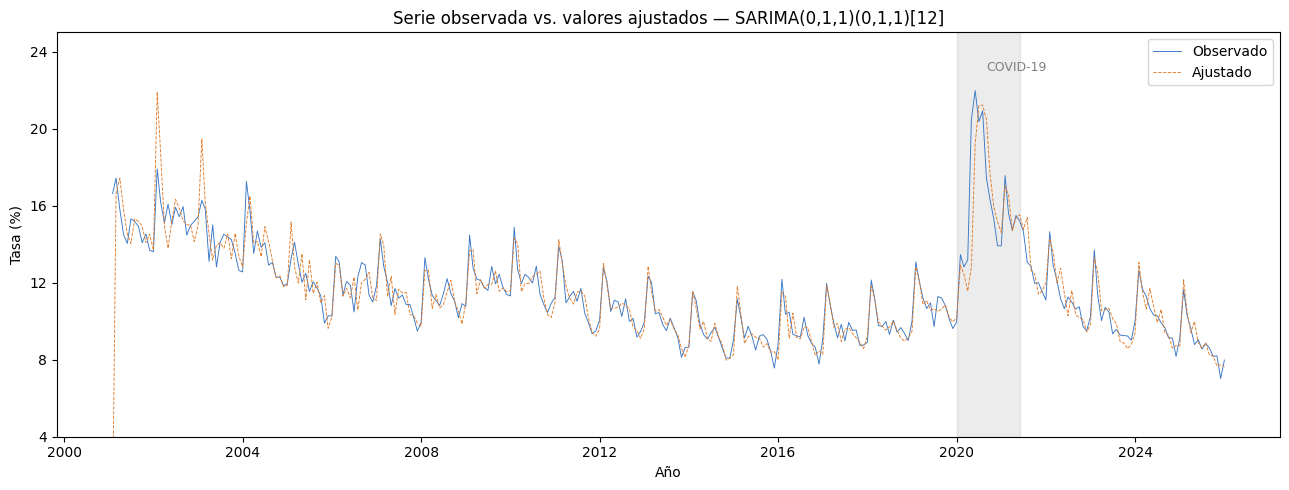

In [30]:
fig, ax = plt.subplots(figsize=(13, 5))

ajustados = modelo_final.fittedvalues

ax.plot(ts_desempleo_nacional.index, ts_desempleo_nacional.values,
        color='#3876c4', linewidth=0.65, label='Observado')
ax.plot(ts_desempleo_nacional.index, ajustados.values,
        color='#e07b2a', linewidth=0.65, linestyle='--', label='Ajustado')

# Franja COVID-19
ax.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-06-01'),
           alpha=0.15, color='grey')
ax.text(pd.Timestamp('2020-09-01'), 23,
        'COVID-19', size=9, color='grey')

ax.set_ylim(4, 25)
ax.set_yticks(range(4, 25, 4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_title('Serie observada vs. valores ajustados — SARIMA(0,1,1)(0,1,1)[12]',
             fontsize=12)
ax.set_xlabel('Año')
ax.set_ylabel('Tasa (%)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

La línea punteada naranja sigue de cerca a la observada durante la mayor parte del período 2001-2025, lo que confirma un buen ajuste en muestra. El único tramo de desajuste visible corresponde al pico de 2020, donde el desempleo superó el 20% como consecuencia del cierre económico por la pandemia: el RMSE dentro de la ventana COVID (ene-2020 a jun-2021) es 2.17, frente a 1.24 en el resto de la serie —casi el doble de error, concentrado por completo en un choque exógeno que ningún modelo univariado de series de tiempo puede anticipar sin información externa adicional.

## Métricas de ajuste y precisión

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

obs  = ts_desempleo_nacional.values
ajus = ajustados.values

rmse = np.sqrt(mean_squared_error(obs, ajus))
mae  = mean_absolute_error(obs, ajus)
mape = np.mean(np.abs((obs - ajus) / obs)) * 100
acf1 = pd.Series(residuos.dropna().values).autocorr(lag=1)

tabla_acc = pd.DataFrame({
    'Metrica': ['RMSE', 'MAE', 'MAPE (%)', 'ACF1 residuos'],
    'Valor':   [round(rmse, 4), round(mae, 4),
                round(mape, 4), round(acf1, 4)]
})

tabla_acc

,Metrica,Valor
0,RMSE,1.3181
1,MAE,0.6433
2,MAPE (%),5.1694
3,ACF1 residuos,0.0580


Un **RMSE de ≈ 1.32** sobre una serie cuyo rango histórico es 7%-22% representa un error relativo reducido, prácticamente idéntico al del SARIMA(2,1,2)(1,1,1)[12] evaluado inicialmente (1.31). El **MAPE de ≈ 5.17%** indica que, en promedio, el modelo se desvía poco más de un 5% del valor real mensual, lo cual es aceptable para una serie macroeconómica con un componente estructural tan marcado como la pandemia —y se logra con un modelo de solo 2 parámetros (más la varianza), frente a los 7 de la especificación inicialmente considerada.

## Conclusiones del modelo

El análisis de series de tiempo aplicado a la tasa de desempleo nacional colombiana (2001-2025) permitió confirmar que la serie presenta las características típicas de un proceso no estacionario con estacionalidad anual: tendencia estocástica, patrón cíclico de 12 meses y un choque estructural severo en 2020. Estas propiedades descartaron el uso de un ARIMA simple y orientaron la selección hacia una familia de modelos **SARIMA(p,d,q)(P,D,Q)[12]**.

La comparación inicial de cinco especificaciones sobre un único corte train/test (270/30) favoreció al SARIMA(2,1,2)(1,1,1)[12] por tener el menor RMSE de validación (0.835). Sin embargo, dos verificaciones adicionales mostraron que esa ventaja no era robusta: (1) ninguno de sus 7 coeficientes resultó estadísticamente significativo al reajustar el modelo, y (2) una validación walk-forward con 6 orígenes distintos en el tiempo lo ubicó como el **peor** de los cuatro candidatos estacionales, no el mejor. En contraste, **SARIMA(0,1,1)(0,1,1)[12]** combinó el mejor AIC/BIC de toda la comparación, el 100% de coeficientes significativos (p < 0.001) y una precisión walk-forward prácticamente idéntica a la del mejor candidato. Por parsimonia y robustez estadística, este fue el modelo adoptado como definitivo.

El diagnóstico de residuos confirma la validez estadística del modelo elegido: las pruebas de Ljung-Box arrojan p-valores de 0.79 y 0.77 para rezagos 12 y 24, respectivamente, indicando que los residuos se comportan como ruido blanco. El análisis de normalidad revela colas más pesadas de lo normal (Jarque-Bera = 7290, curtosis = 27.2) y heterocedasticidad (H = 1.70, p = 0.01), atribuibles casi en su totalidad al episodio de 2020 (RMSE dentro de la ventana COVID = 2.17 frente a 1.24 fuera de ella). Esto no compromete la estructura de autocorrelación del modelo, pero sí implica que los intervalos de confianza del pronóstico deben interpretarse como una aproximación.

Los pronósticos para 2026 proyectan una **tasa de desempleo en el rango 7.1%-11.0%**, con un patrón estacional consistente con el comportamiento histórico —prácticamente el mismo rango que arrojaba la especificación más compleja, pero ahora respaldado por un modelo de 2 parámetros en lugar de 7. Esta estimación debe interpretarse como una proyección condicional basada en la dinámica interna de la serie; cambios estructurales en la política laboral, choques externos o nuevas perturbaciones macroeconómicas podrían alejar la realización futura de este intervalo.

Finalmente, este resultado es coherente con las hipótesis planteadas en la introducción del proyecto: la tasa de desempleo muestra patrones cíclicos y estacionales modelables a partir de su propio comportamiento pasado, y el choque del COVID-19 constituyó una ruptura estadísticamente diferenciable del comportamiento histórico previo. El ejercicio adicional de validación realizado aquí ilustra, además, un punto metodológico general: comparar modelos con una sola métrica y un solo corte de datos puede llevar a elegir una especificación sobreajustada; la significancia de los parámetros y la validación con múltiples orígenes son verificaciones necesarias antes de fijar un modelo como definitivo.

# Referencias

Arango, L., Herrera, P., & Posada, C. (2008). Comisión Permanente de Concertación de Políticas Salariales y Laborales. *Ensayos sobre Política Económica*, 26(56), 204–263.

Banco de la República de Colombia. (2021). *Informe de Política Monetaria*. https://www.banrep.gov.co

Banco de la República de Colombia. (2022). *Mercado laboral en Colombia: tendencias y retos estructurales*. https://www.banrep.gov.co/es/estadisticas-economicas/series-historicas/mercado-laboral

Banco de la República de Colombia. (s. f.). Series estadísticas históricas: Mercado laboral. https://uba.banrep.gov.co/htmlcommons/SeriesHistoricas/mercado-laboral.html

Blanchard, O. (2017). *Macroeconomics* (7.ª ed.). Pearson.

Blanchard, O., & Diamond, P. (1989). The Beveridge curve. *Brookings Papers on Economic Activity*, 1989(1), 1–76.

Blanchard, O., & Summers, L. H. (1987). Hysteresis in unemployment. *European Economic Review*, 31(1–2), 288–295.

Box, G. E. P., & Jenkins, G. M. (1970). *Time Series Analysis: Forecasting and Control*. Holden-Day.

Congreso de la República de Colombia. (1945). *Ley 6 de 1945: Disposiciones sobre convenciones de trabajo, asociaciones profesionales, conflictos colectivos y jurisdicción especial de trabajo*.

Departamento Administrativo Nacional de Estadística (DANE). (2020). *Gran Encuesta Integrada de Hogares — resultados 2020*. https://www.dane.gov.co/index.php/estadisticas-por-tema/mercado-laboral/empleo-y-desempleo/geih-historicos

Departamento Administrativo Nacional de Estadística (DANE). (2023). *Mercado laboral — metodología y resultados*. https://www.dane.gov.co/index.php/estadisticas-por-tema/mercado-laboral

Friedman, M. (1968). The role of monetary policy. *The American Economic Review*, 58(1), 1–17.

Hyndman, R. J., & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice* (3.ª ed.). OTexts. https://otexts.com/fpp3/

Keynes, J. M. (1936). *The General Theory of Employment, Interest and Money*. Macmillan.

Lora, E., & Pagés, C. (2010). *La realidad del mercado laboral*. Banco Interamericano de Desarrollo.

Mankiw, N. G. (2015). *Principles of Economics* (7.ª ed.). Cengage Learning.

Organización Internacional del Trabajo. (2023). *Population and labour force*. https://ilostat.ilo.org/es/topics/population-and-labour-force/

Pissarides, C. A. (2000). *Equilibrium Unemployment Theory* (2.ª ed.). MIT Press.

Posada, C. E., & Ospina, M. (2012). La ley y el mercado laboral en Colombia. *Borradores de Economía*, Banco de la República.
